In [12]:
# Don't overwrite
%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


# C=1 Gibbs sampler — per-iteration diagnostic

The two EV hypotheses are inferred by **completely separate** procedures
(specs/model.md §4); they share no information.

- **C = 0 (no EV)** needs *no sampling*: z^EV is pinned off and the model
  collapses to the Non-EV daily LDS, whose posterior over z^LDS is exact (one
  Kalman smoother call). Section 7 runs it and compares the two hypotheses.
- **C = 1 (EV)** is a three-block Gibbs sampler over (Θ, z^EV, z^LDS). This
  notebook steps through that sampler one block at a time for a chosen test home
  over a chosen range of iterations:

  1. **Block A**: sample $z^{EV} \mid \Theta, z^{LDS}$ via HMM forward-filter
     backward-sample. Per selected day we show three strips: ground truth, the
     drawn sample, and the **fuzzy posterior** — the per-cell HMM marginal
     $\gamma_{d,t}(k)$ rendered as the mass-weighted blend of the state colours.
  2. **Block B**: sample $\Theta_k$ for $k \in \{\mathrm{low},\mathrm{high}\}$
     from its truncated-Normal posterior; posterior $(m,\sigma)$ and sufficient
     statistics are reported alongside the draw.
  3. **Block C**: sample $z^{LDS}$ via Kalman FFBS — before/after Non-EV mean
     for the selected days.

At the end of each iteration: predicted vs ground-truth Non-EV / EV / Total
power over the same days. Then trace plots over the narrated range, and finally
(§7) the exact C=0 fit and the **$\log p(x, C{=}0)$ vs $\log p(x, C{=}1)$**
comparison.

Helpers live in `notebooks/utils/gibbs_diagnostics.py`.

## 1. Imports + load fitted params + test split

In [13]:
import sys, pickle
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

PROJECT_ROOT = Path('../..').resolve()
sys.path.insert(0, str(PROJECT_ROOT))
sys.path.insert(0, str(PROJECT_ROOT / 'notebooks' / 'utils'))

from data_utils  import load_split
import gibbs_diagnostics as gd
from models import graphical_model as gm

In [14]:
# ── CONFIGURE ──────────────────────────────────────────────────────────────
FITTED_PARAMS_PATH = PROJECT_ROOT / 'models' / 'fitted_params_0.001I.pkl'
SPLIT_PATH         = PROJECT_ROOT / 'data_processing' / 'splits' / 'train.pkl'
# ───────────────────────────────────────────────────────────────────────────

with open(FITTED_PARAMS_PATH, 'rb') as f:
    params: gm.ModelParams = pickle.load(f)
df = load_split(str(SPLIT_PATH))
T  = gm.T
print(f'Loaded params from {FITTED_PARAMS_PATH.name}')
print(f'Loaded {len(df):,} rows, {df.home_id.nunique()} homes')

Loaded params from fitted_params_0.001I.pkl
Loaded 1,543,872 rows, 54 homes


## 2. Available homes

Table of `(home_id, true_C, D)` for the split. Pick one for `HOME_ID` below.

In [15]:
home_summary = (
    df.groupby('home_id')
      .agg(true_c=('has_ev', 'first'),
           D     =('day',    'nunique'))
      .reset_index()
      .sort_values(['true_c', 'home_id'], ascending=[False, True])
)
home_summary['true_c'] = home_summary['true_c'].astype(int)
with pd.option_context('display.max_rows', None):
    print(home_summary.to_string(index=False))

 home_id  true_c   D
      27       1 183
     661       1 350
    3000       1 182
    4373       1 354
    4767       1 358
    6139       1 277
    7719       1 356
    8156       1 358
    9053       1 183
     203       0 360
     387       0 183
     558       0 183
     914       0 183
     950       0 183
    1240       0 183
    1450       0 360
    1524       0 360
    1731       0 355
    2096       0 183
    2335       0 353
    2358       0 183
    2361       0 358
    2606       0 360
    2818       0 358
    3039       0 341
    3456       0 358
    3488       0 183
    3538       0 360
    3687       0 360
    3700       0 183
    3864       0 360
    3938       0 361
    3996       0 183
    4031       0 360
    4283       0 183
    4550       0 183
    4934       0 361
    5058       0 183
    5938       0 361
    5982       0 183
    5997       0 183
    6377       0 360
    6547       0 360
    7062       0 360
    7536       0 358
    7901       0 357
    7951     

## 3. Pick a home + a range of iterations

`NARRATE_RANGE = (start, end)` is **inclusive of `start`, exclusive of `end`**:
the chain runs `start` silent iterations, then narrates iterations
`start, start+1, …, end-1`.

`DAYS_TO_SHOW` controls the z^LDS line plot; the same days are shown across
all narrated iterations so the changes are directly comparable.

In [16]:
# ── CONFIGURE ──────────────────────────────────────────────────────────────
HOME_ID        = 27        # pick from the table above
NARRATE_RANGE  = (0, 10)      # (start, end) — run `start` silent then narrate end-start iters
SEED           = 0
DAYS_TO_SHOW   = [0, 30, 60, 90]   # days used in z^EV / z^LDS / power-decomp plots, consistent across iters
# ───────────────────────────────────────────────────────────────────────────

g          = df[df['home_id'] == HOME_ID].sort_values(['day', 'time_index'])
D          = g['day'].nunique()
home_x     = g['total_load'].to_numpy().reshape(D, T).astype(np.float64)
x_nev_true = g['non_ev_load'].to_numpy().reshape(D, T).astype(np.float64)
x_ev_true  = g['ev_load'].to_numpy().reshape(D, T).astype(np.float64)
z_true     = g['charge_state'].to_numpy().reshape(D, T).astype(np.int64)
true_c     = int(g['has_ev'].iloc[0])

silent_iters  = NARRATE_RANGE[0]
narrate_iters = NARRATE_RANGE[1] - NARRATE_RANGE[0]
assert narrate_iters > 0, 'NARRATE_RANGE must be non-empty'
assert all(0 <= d < D for d in DAYS_TO_SHOW), f'DAYS_TO_SHOW must be in [0, {D})'

print(f'Home {HOME_ID}: D={D} days, true_C={true_c}')
print(f'Silent iters: {silent_iters}, narrate iters: '
      f'{NARRATE_RANGE[0]} … {NARRATE_RANGE[1] - 1}')
print(f'Days shown across plots: {DAYS_TO_SHOW}')

Home 27: D=183 days, true_C=1
Silent iters: 0, narrate iters: 0 … 9
Days shown across plots: [0, 30, 60, 90]


## 4. Run the chain

`run_diagnostic` advances the chain silently through `silent_iters`, then
captures full intermediates for `narrate_iters` more iterations. The returned
`records` is a list of `IterRecord`s, one per narrated iter.

In [17]:
records, final_state = gd.run_diagnostic(
    home_x, params,
    silent_iters  = silent_iters,
    narrate_iters = narrate_iters,
    seed          = SEED,
)

  Running C=1 silent for 0 iterations …
  Done. Now narrating iterations 0 … 9


## 5. Per-iteration narration

One section per narrated C=1 sweep: Block A (z^EV), Block B (Θ), Block C (z^LDS).

The z^EV colour scheme uses **one viridis colour per state** (no correctness
tinting):

- purple = off
- teal   = low
- yellow = high

Each day shows three strips — **ground truth | sample | posterior γ**. The first
two are discrete (one colour per cell); the posterior strip blends the three
colours by the per-cell HMM marginal mass (e.g. 0.1·purple + 0.2·teal +
0.7·yellow for γ = (0.1, 0.2, 0.7)).


══════════════════════════════════════════════════════════════════════════════
  Iteration 0   (C = 1 fixed)
══════════════════════════════════════════════════════════════════════════════

  ── Block A: sample z^EV | Θ, z^LDS  (HMM FFBS) ──────────────────────
    state freq before : off=1.000 low=0.000 high=0.000
    state freq after  : off=1.000 low=0.000 high=0.000
    cells changed     : 1 / 17,568


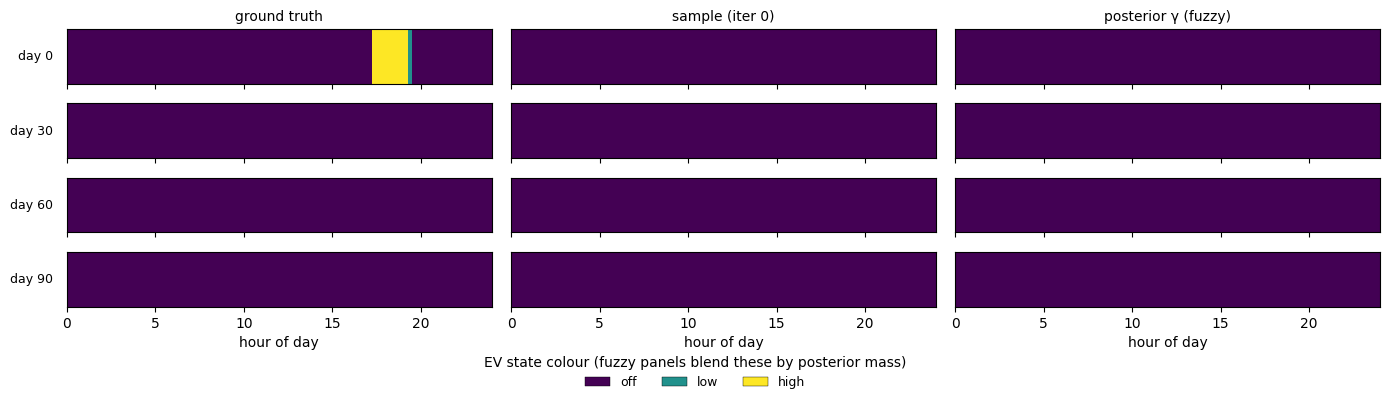


  ── Block B: sample Θ_k for k ∈ {low, high} ──────────────────────────
    Θ_ low  : m=+0.8125  sd=0.1279  trunc=[0.1, 2.0]  n_cells=    1   →  drawn=+0.7305
    Θ_high  : m=+3.5616  sd=0.6219  trunc=[2.0, ∞]  n_cells=    0   →  drawn=+3.9954  (no z=k cells — sampled from prior)


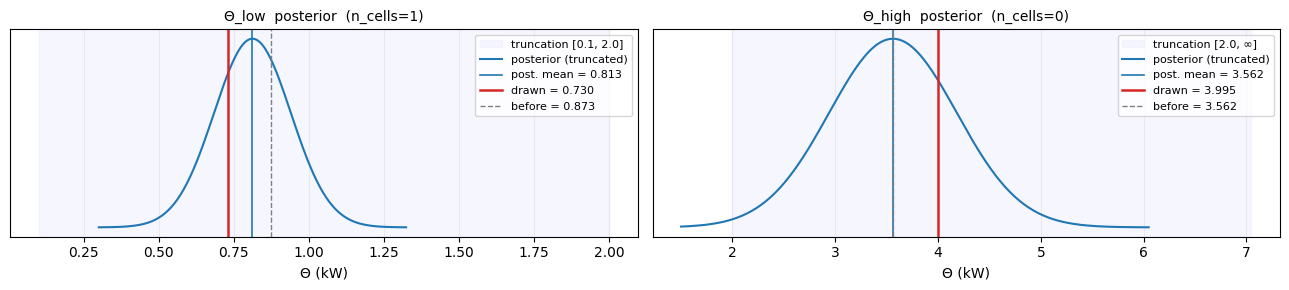


  ── Block C: sample z^LDS | z^EV, Θ  (Kalman FFBS) ───────────────────
    mean |Δ(C z^LDS)| across (d,t) = 0.0253 kW
    std of after - before          = 0.0321 kW


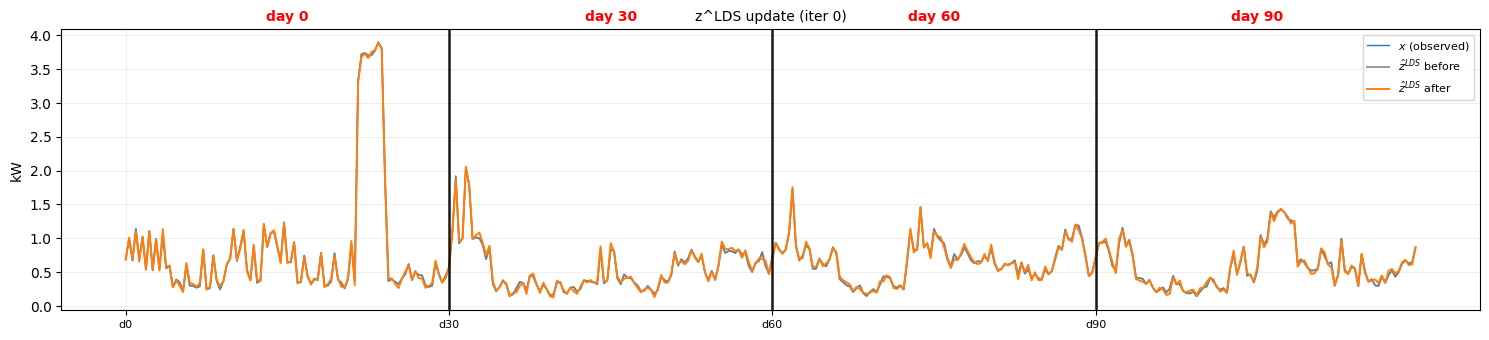


  ── End of iter 0:  complete-data logL = +44493.42
    Power decomposition (predicted vs true) across the chosen days:


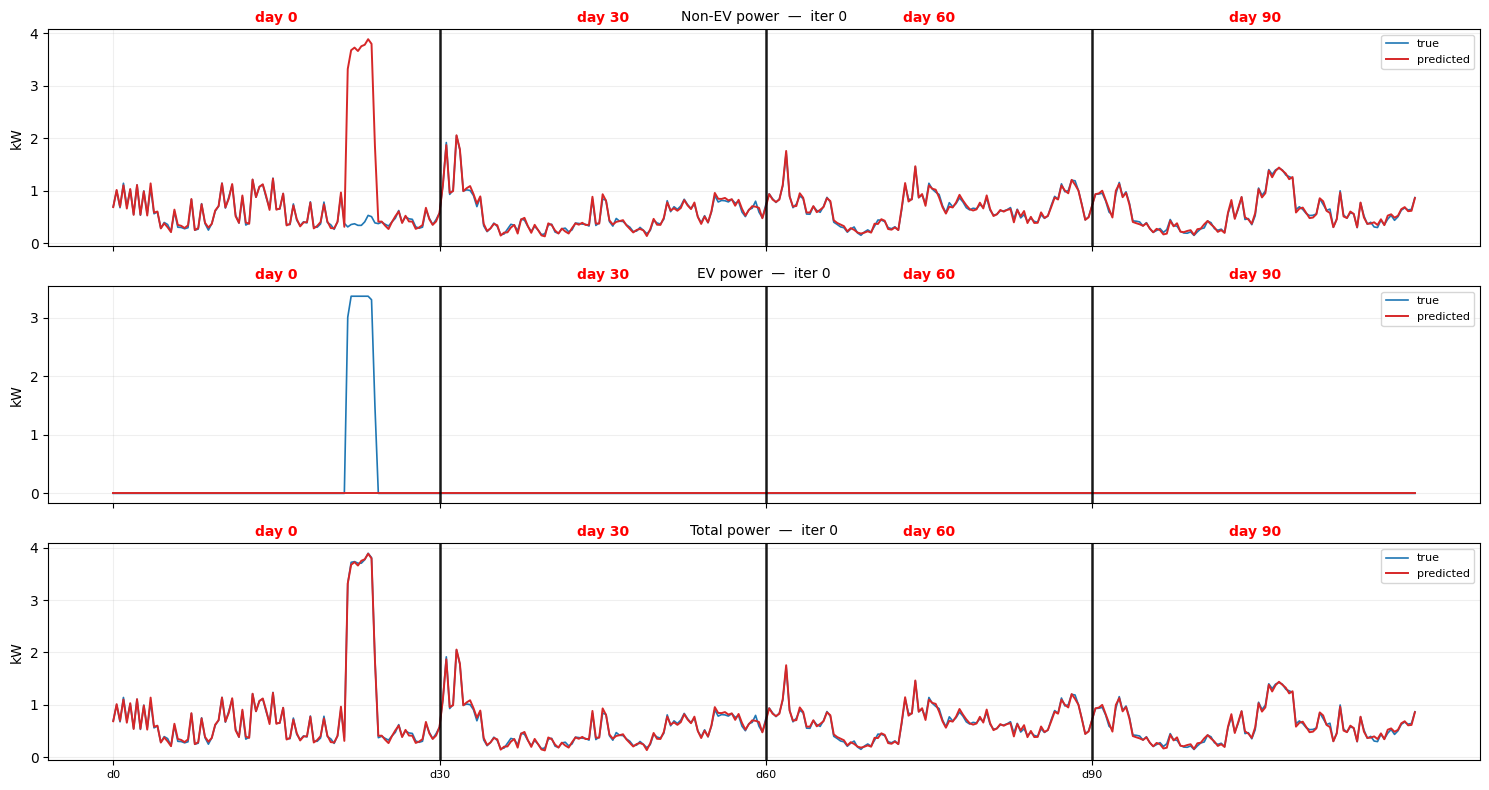


══════════════════════════════════════════════════════════════════════════════
  Iteration 1   (C = 1 fixed)
══════════════════════════════════════════════════════════════════════════════

  ── Block A: sample z^EV | Θ, z^LDS  (HMM FFBS) ──────────────────────
    state freq before : off=1.000 low=0.000 high=0.000
    state freq after  : off=1.000 low=0.000 high=0.000
    cells changed     : 4 / 17,568


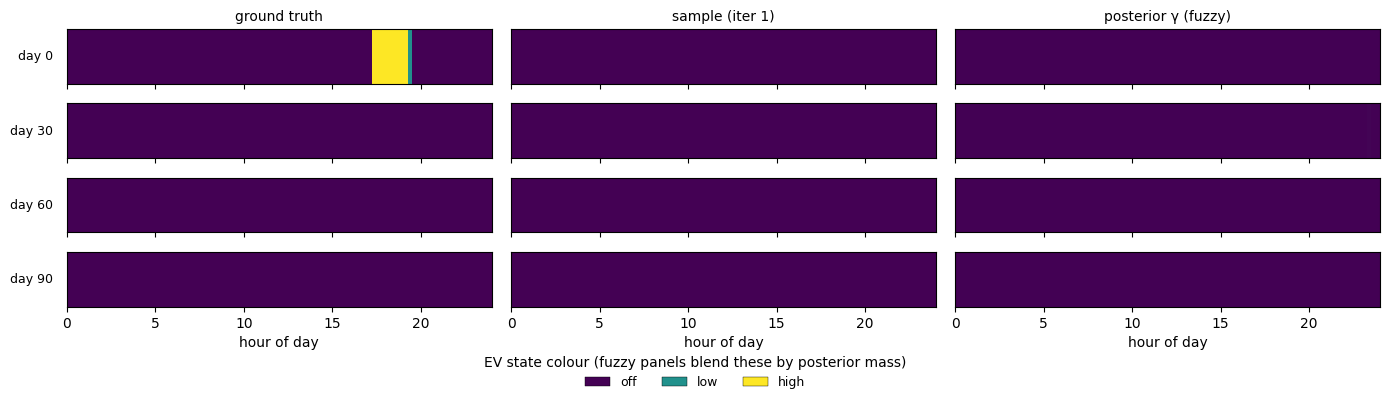


  ── Block B: sample Θ_k for k ∈ {low, high} ──────────────────────────
    Θ_ low  : m=+0.6753  sd=0.1133  trunc=[0.1, 2.0]  n_cells=    5   →  drawn=+0.8049
    Θ_high  : m=+3.5616  sd=0.6219  trunc=[2.0, ∞]  n_cells=    0   →  drawn=+3.5006  (no z=k cells — sampled from prior)


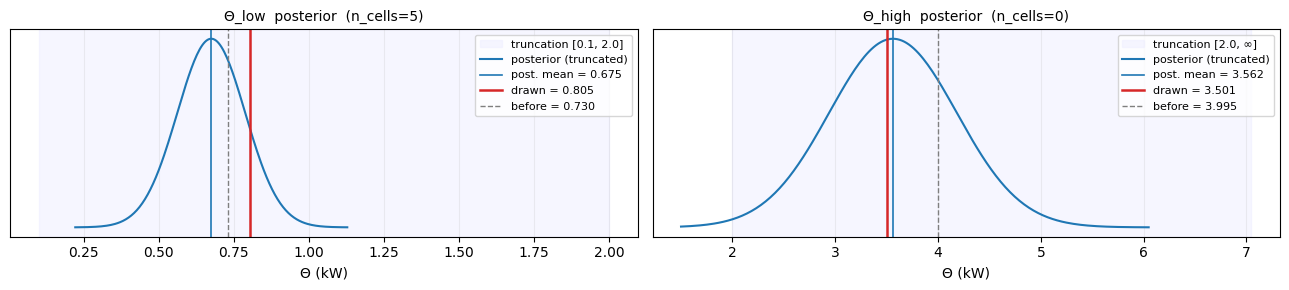


  ── Block C: sample z^LDS | z^EV, Θ  (Kalman FFBS) ───────────────────
    mean |Δ(C z^LDS)| across (d,t) = 0.0360 kW
    std of after - before          = 0.0458 kW


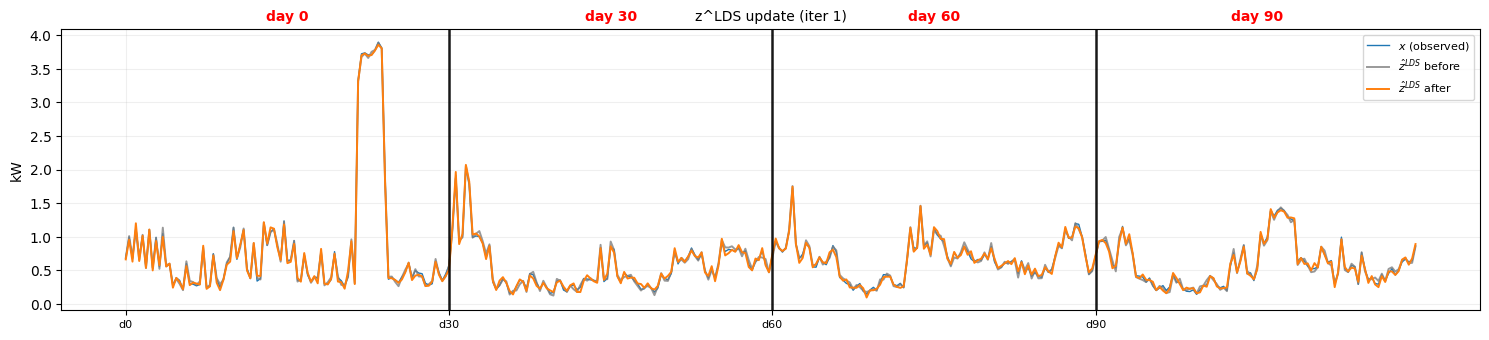


  ── End of iter 1:  complete-data logL = +35707.93
    Power decomposition (predicted vs true) across the chosen days:


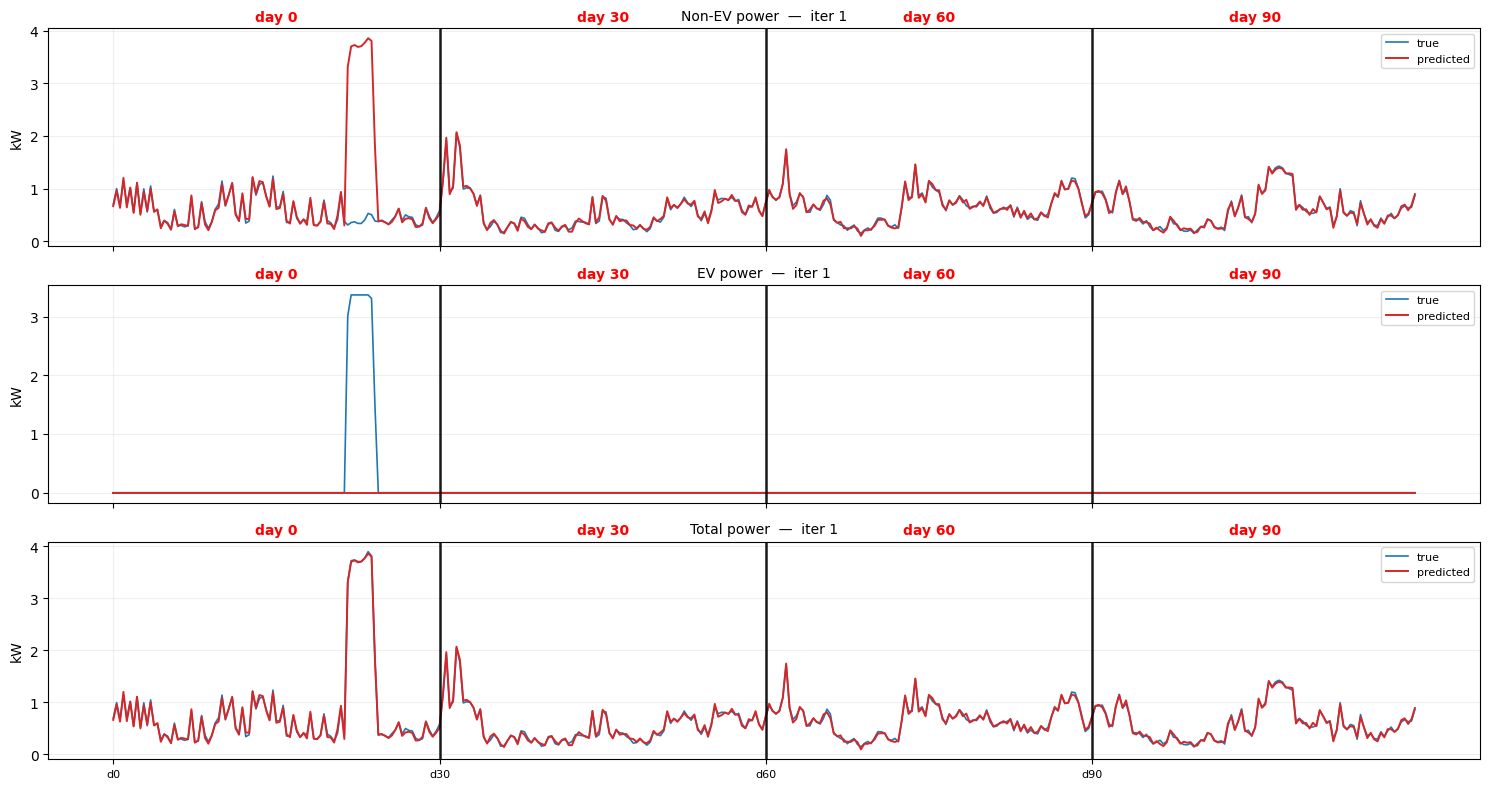


══════════════════════════════════════════════════════════════════════════════
  Iteration 2   (C = 1 fixed)
══════════════════════════════════════════════════════════════════════════════

  ── Block A: sample z^EV | Θ, z^LDS  (HMM FFBS) ──────────────────────
    state freq before : off=1.000 low=0.000 high=0.000
    state freq after  : off=1.000 low=0.000 high=0.000
    cells changed     : 3 / 17,568


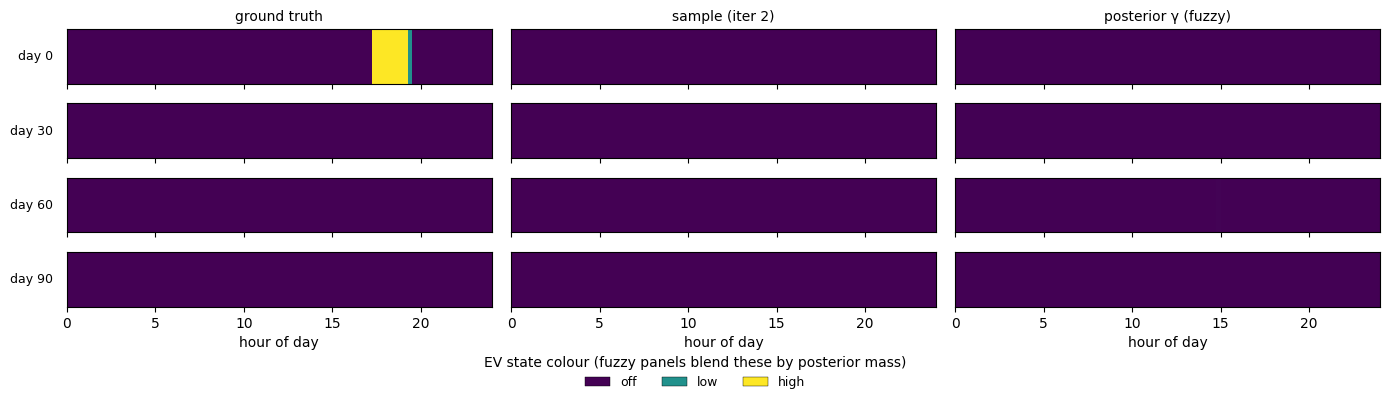


  ── Block B: sample Θ_k for k ∈ {low, high} ──────────────────────────
    Θ_ low  : m=+0.7556  sd=0.1103  trunc=[0.1, 2.0]  n_cells=    6   →  drawn=+0.8065
    Θ_high  : m=+3.5616  sd=0.6219  trunc=[2.0, ∞]  n_cells=    0   →  drawn=+2.8771  (no z=k cells — sampled from prior)


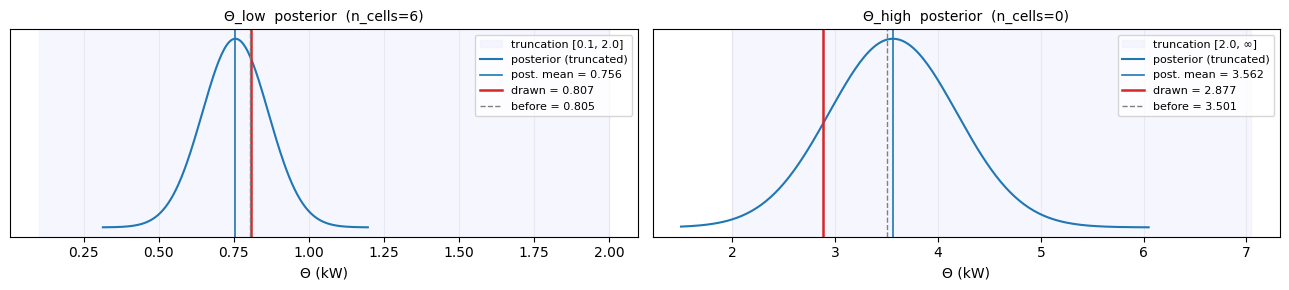


  ── Block C: sample z^LDS | z^EV, Θ  (Kalman FFBS) ───────────────────
    mean |Δ(C z^LDS)| across (d,t) = 0.0358 kW
    std of after - before          = 0.0459 kW


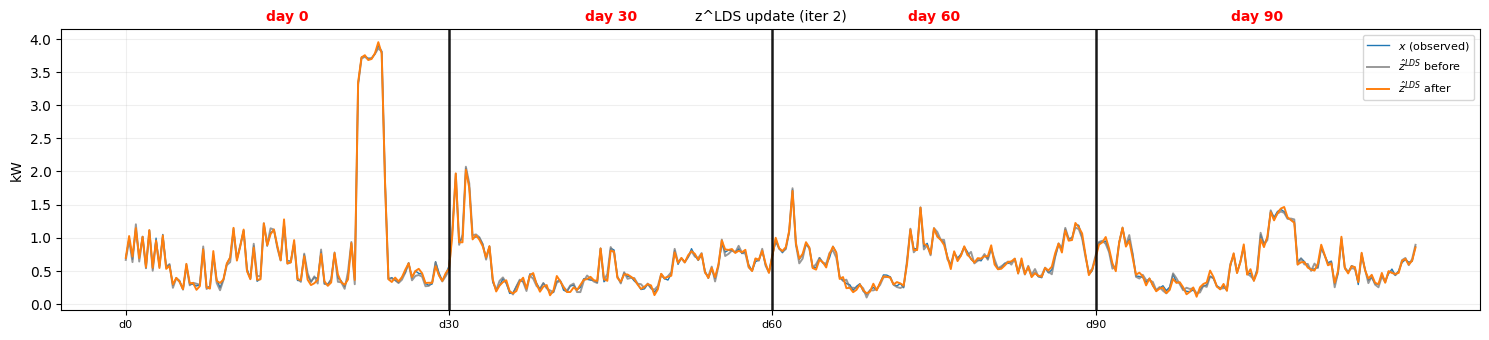


  ── End of iter 2:  complete-data logL = +35823.26
    Power decomposition (predicted vs true) across the chosen days:


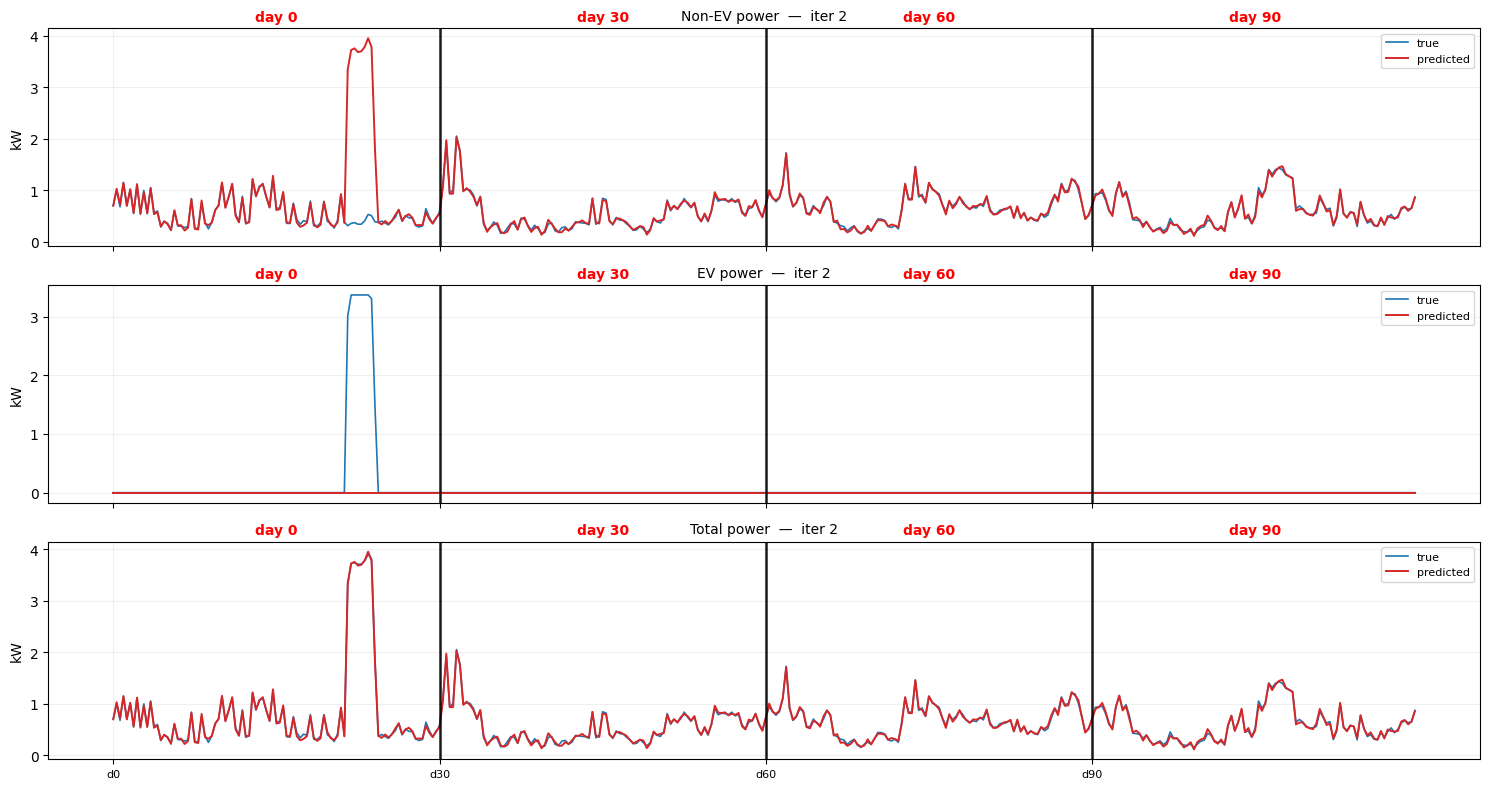


══════════════════════════════════════════════════════════════════════════════
  Iteration 3   (C = 1 fixed)
══════════════════════════════════════════════════════════════════════════════

  ── Block A: sample z^EV | Θ, z^LDS  (HMM FFBS) ──────────────────────
    state freq before : off=1.000 low=0.000 high=0.000
    state freq after  : off=0.999 low=0.001 high=0.000
    cells changed     : 7 / 17,568


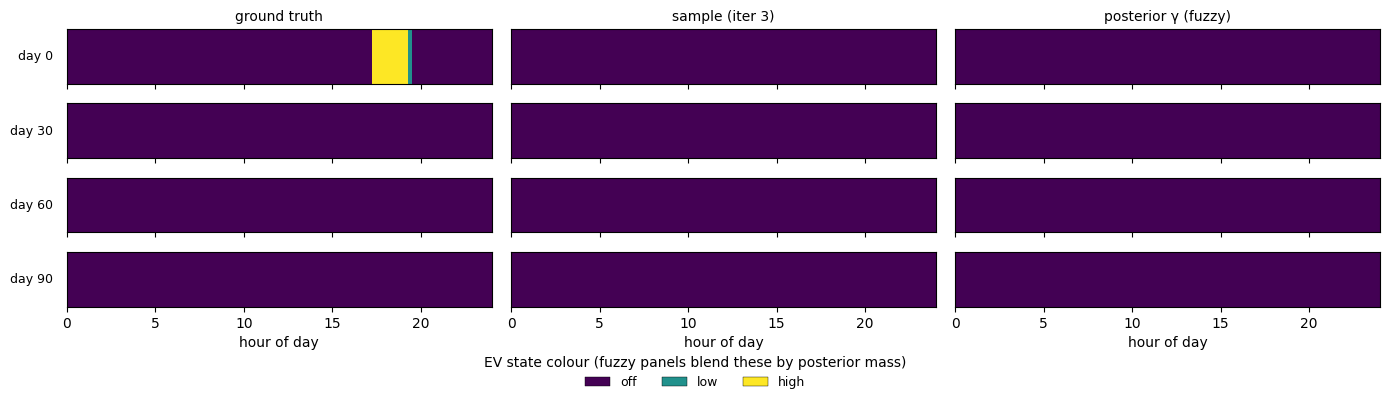


  ── Block B: sample Θ_k for k ∈ {low, high} ──────────────────────────
    Θ_ low  : m=+0.6906  sd=0.1027  trunc=[0.1, 2.0]  n_cells=    9   →  drawn=+0.7835
    Θ_high  : m=+3.5616  sd=0.6219  trunc=[2.0, ∞]  n_cells=    0   →  drawn=+4.1873  (no z=k cells — sampled from prior)


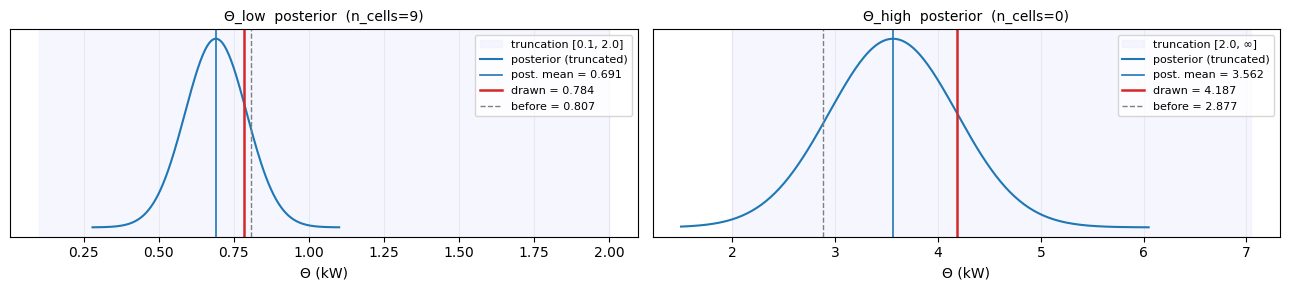


  ── Block C: sample z^LDS | z^EV, Θ  (Kalman FFBS) ───────────────────
    mean |Δ(C z^LDS)| across (d,t) = 0.0359 kW
    std of after - before          = 0.0468 kW


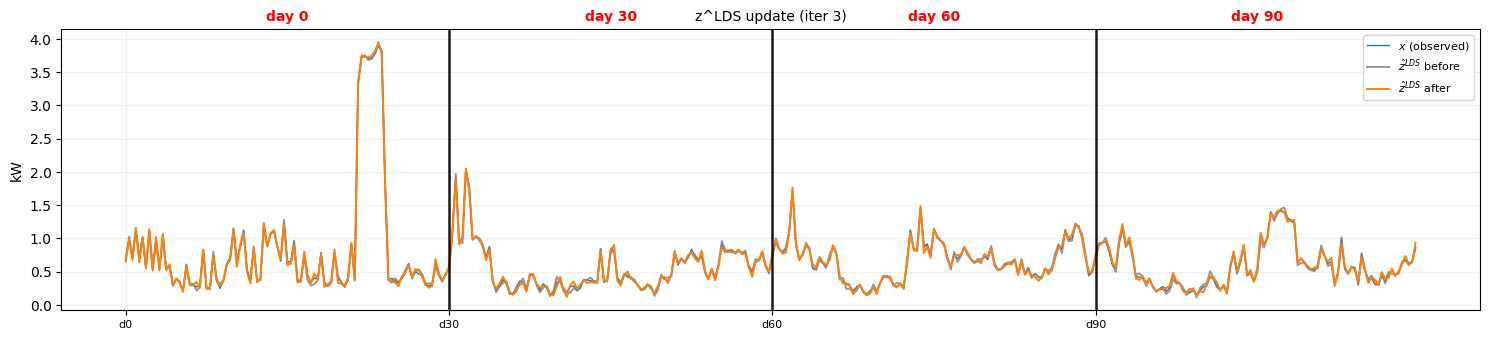


  ── End of iter 3:  complete-data logL = +35706.34
    Power decomposition (predicted vs true) across the chosen days:


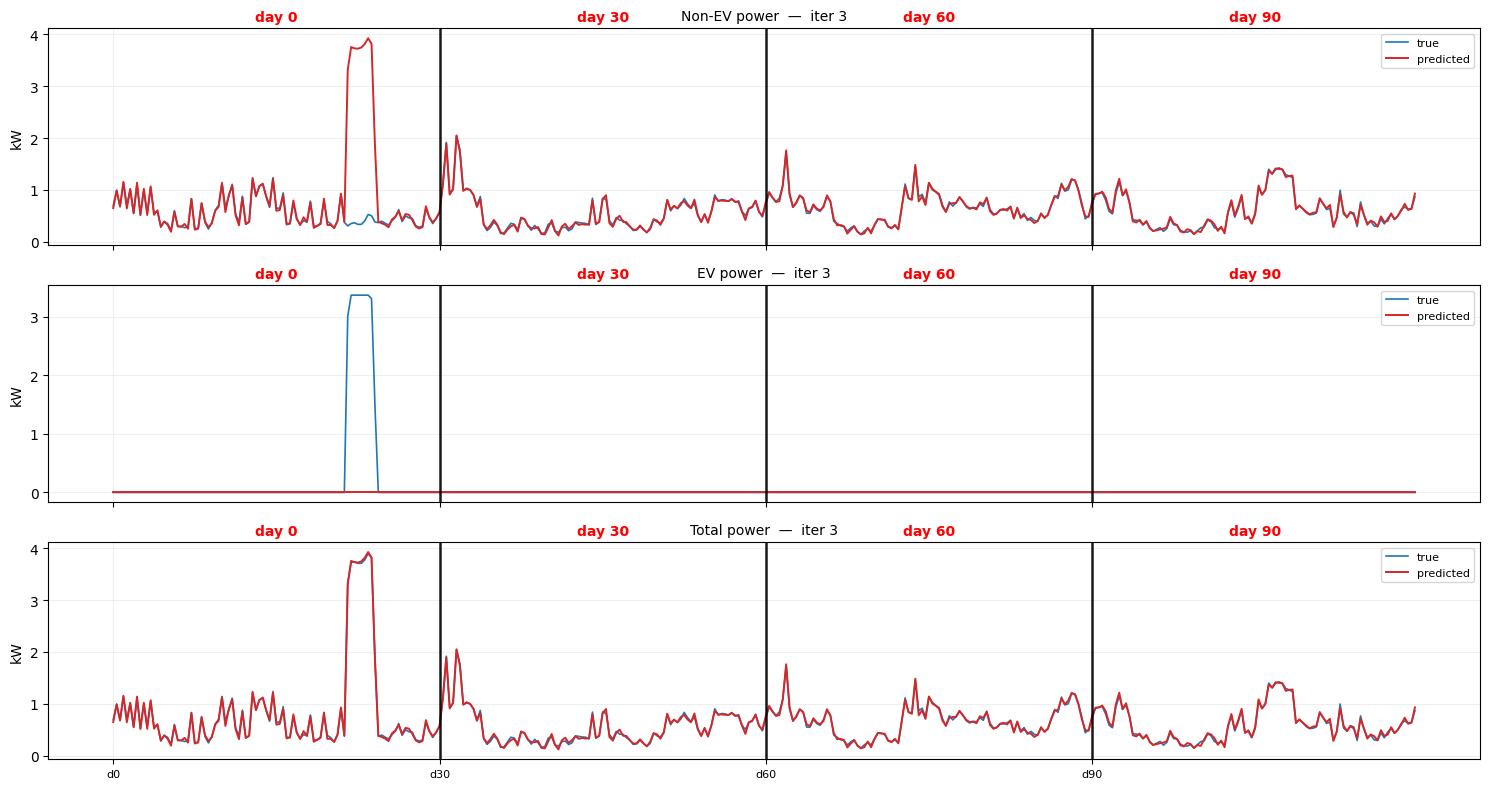


══════════════════════════════════════════════════════════════════════════════
  Iteration 4   (C = 1 fixed)
══════════════════════════════════════════════════════════════════════════════

  ── Block A: sample z^EV | Θ, z^LDS  (HMM FFBS) ──────────────────────
    state freq before : off=0.999 low=0.001 high=0.000
    state freq after  : off=0.999 low=0.001 high=0.000
    cells changed     : 5 / 17,568


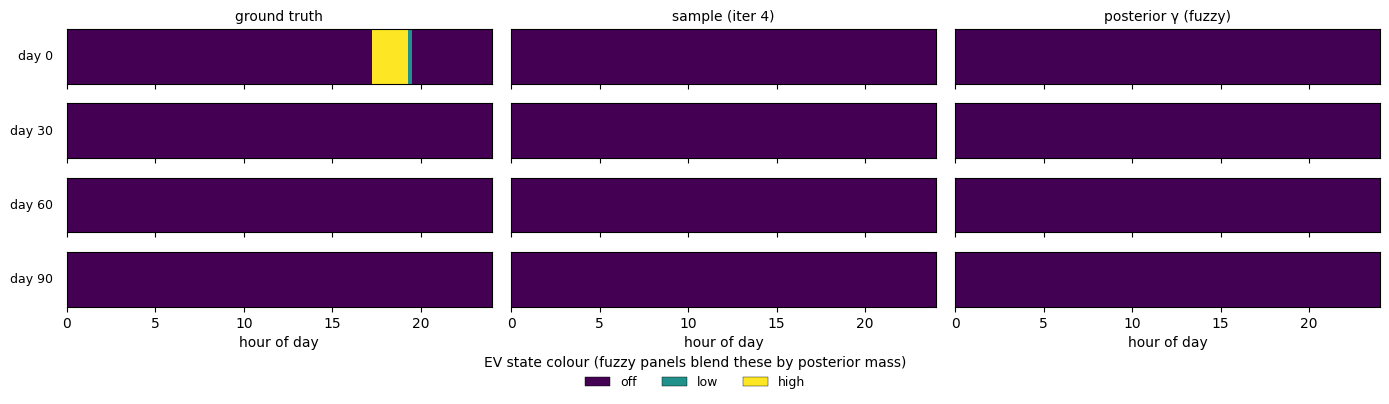


  ── Block B: sample Θ_k for k ∈ {low, high} ──────────────────────────
    Θ_ low  : m=+0.6632  sd=0.0965  trunc=[0.1, 2.0]  n_cells=   12   →  drawn=+0.6793
    Θ_high  : m=+3.5616  sd=0.6219  trunc=[2.0, ∞]  n_cells=    0   →  drawn=+2.8726  (no z=k cells — sampled from prior)


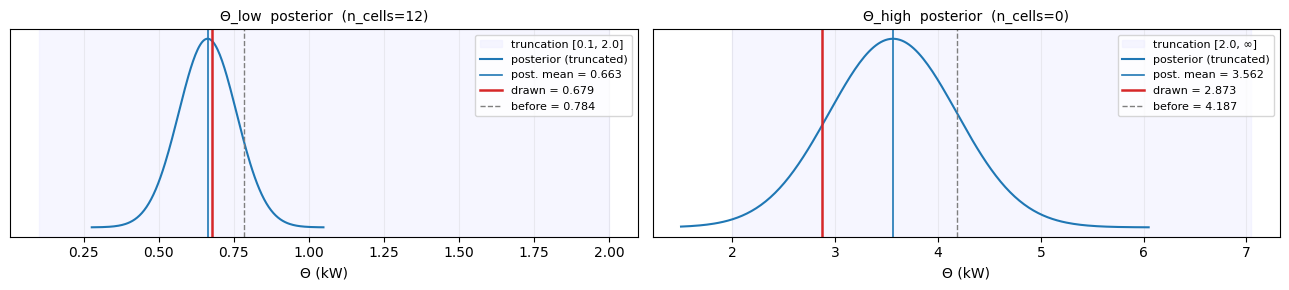


  ── Block C: sample z^LDS | z^EV, Θ  (Kalman FFBS) ───────────────────
    mean |Δ(C z^LDS)| across (d,t) = 0.0360 kW
    std of after - before          = 0.0470 kW


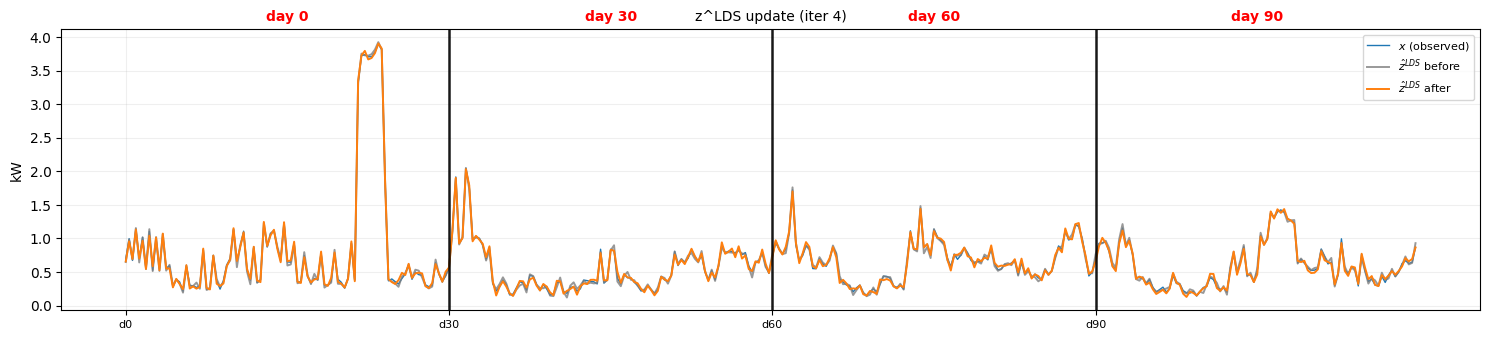


  ── End of iter 4:  complete-data logL = +35687.06
    Power decomposition (predicted vs true) across the chosen days:


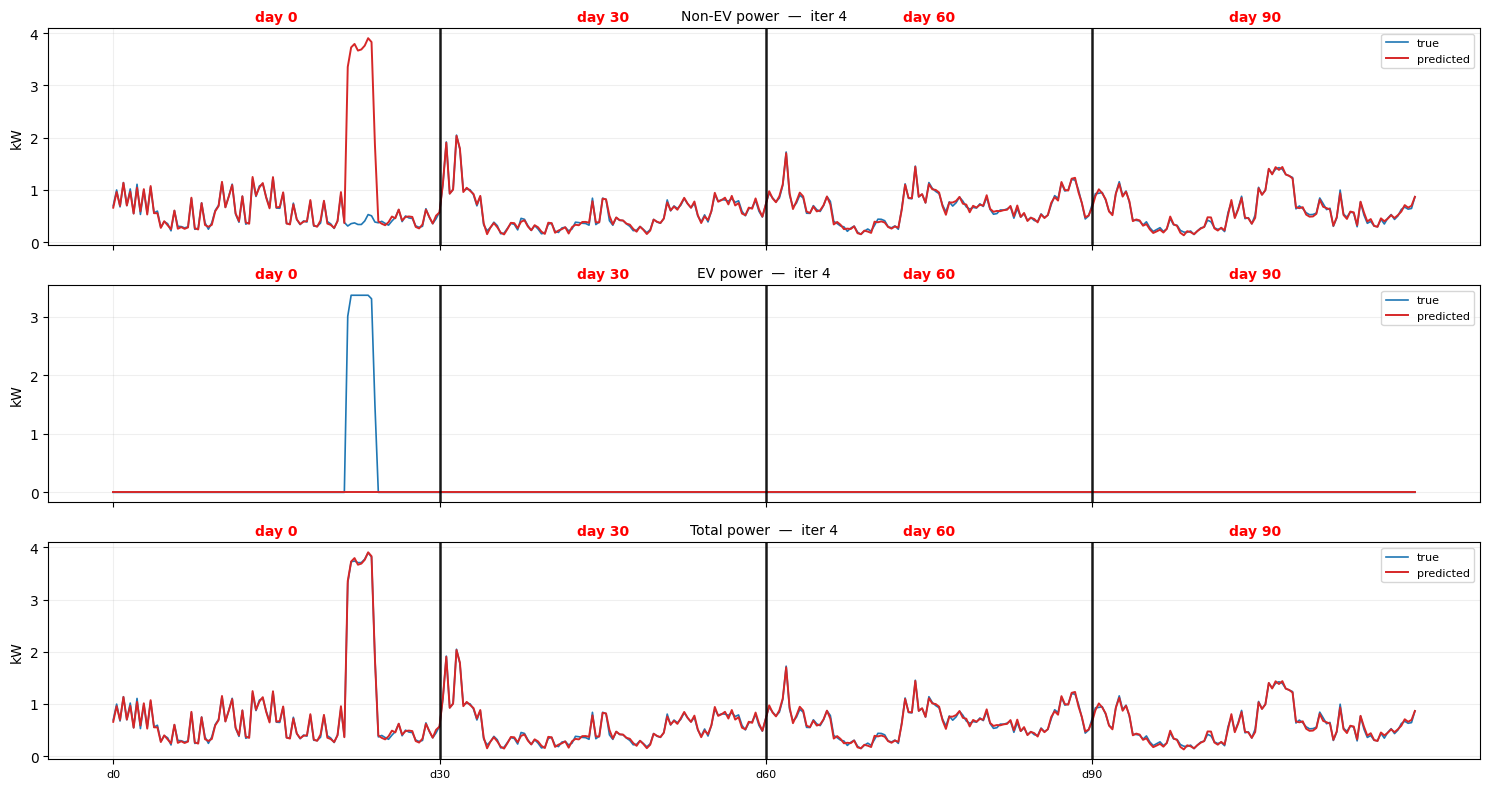


══════════════════════════════════════════════════════════════════════════════
  Iteration 5   (C = 1 fixed)
══════════════════════════════════════════════════════════════════════════════

  ── Block A: sample z^EV | Θ, z^LDS  (HMM FFBS) ──────────────────────
    state freq before : off=0.999 low=0.001 high=0.000
    state freq after  : off=0.999 low=0.001 high=0.000
    cells changed     : 8 / 17,568


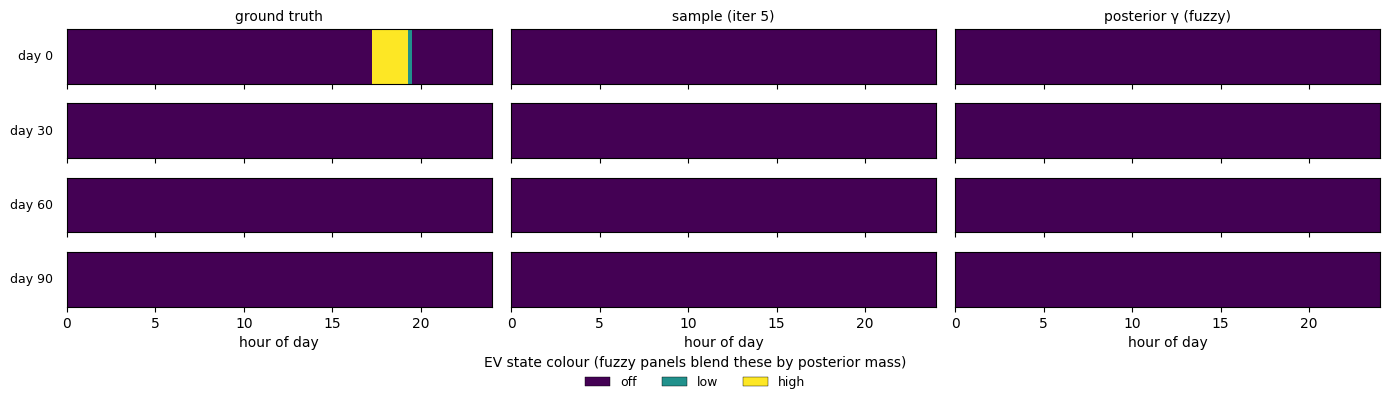


  ── Block B: sample Θ_k for k ∈ {low, high} ──────────────────────────
    Θ_ low  : m=+0.4847  sd=0.0868  trunc=[0.1, 2.0]  n_cells=   18   →  drawn=+0.4865
    Θ_high  : m=+3.5616  sd=0.6219  trunc=[2.0, ∞]  n_cells=    0   →  drawn=+3.9145  (no z=k cells — sampled from prior)


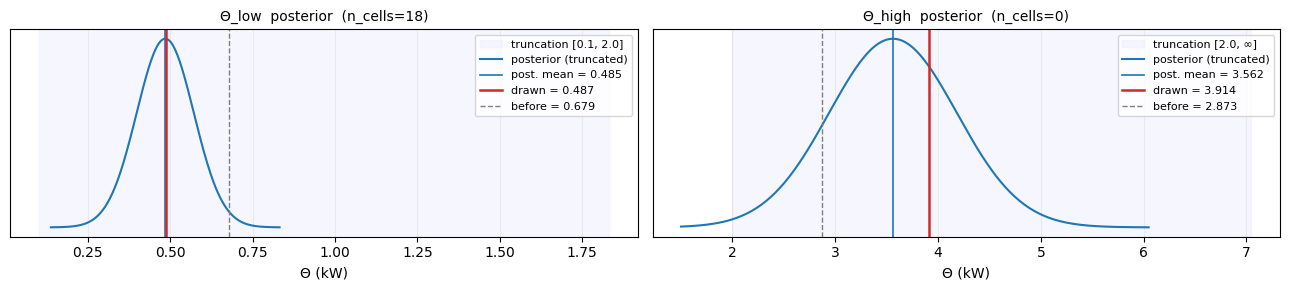


  ── Block C: sample z^LDS | z^EV, Θ  (Kalman FFBS) ───────────────────
    mean |Δ(C z^LDS)| across (d,t) = 0.0361 kW
    std of after - before          = 0.0477 kW


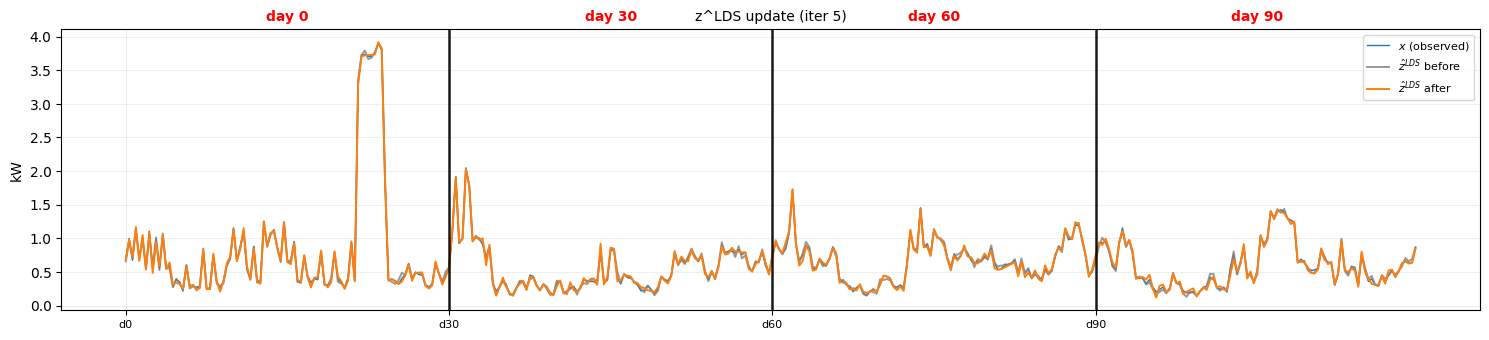


  ── End of iter 5:  complete-data logL = +35593.56
    Power decomposition (predicted vs true) across the chosen days:


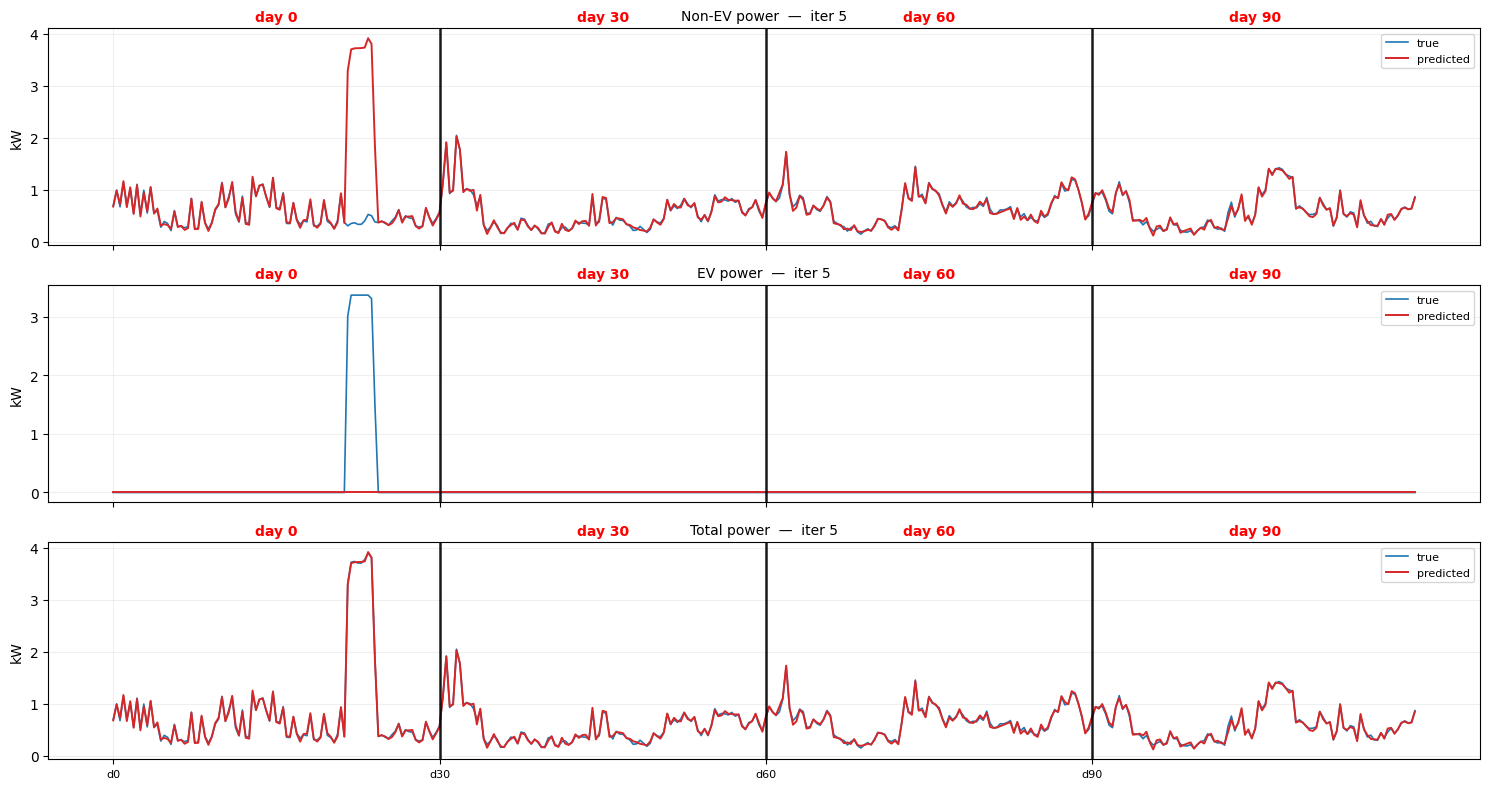


══════════════════════════════════════════════════════════════════════════════
  Iteration 6   (C = 1 fixed)
══════════════════════════════════════════════════════════════════════════════

  ── Block A: sample z^EV | Θ, z^LDS  (HMM FFBS) ──────────────────────
    state freq before : off=0.999 low=0.001 high=0.000
    state freq after  : off=0.999 low=0.001 high=0.000
    cells changed     : 10 / 17,568


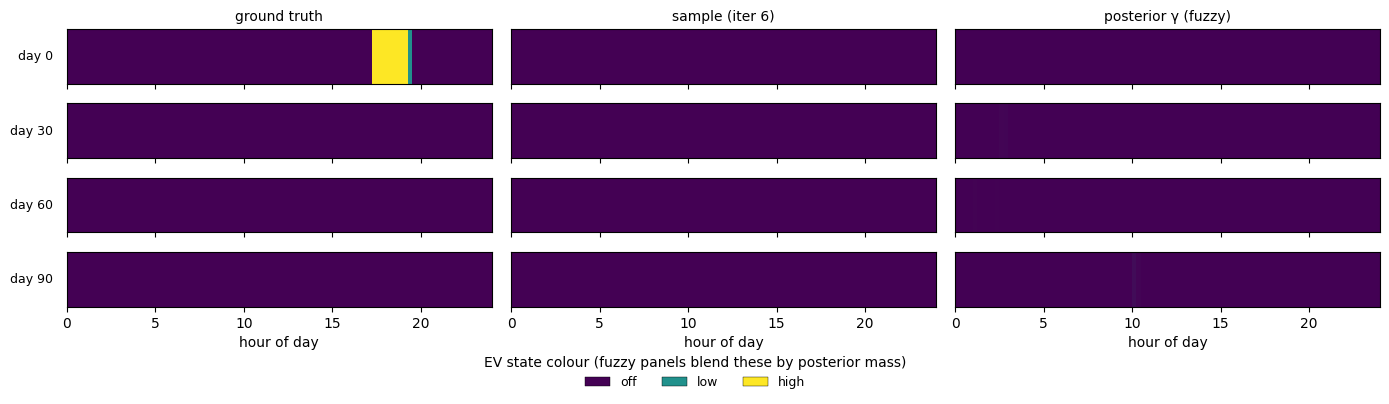


  ── Block B: sample Θ_k for k ∈ {low, high} ──────────────────────────
    Θ_ low  : m=+0.4193  sd=0.0775  trunc=[0.1, 2.0]  n_cells=   26   →  drawn=+0.4316
    Θ_high  : m=+3.5616  sd=0.6219  trunc=[2.0, ∞]  n_cells=    0   →  drawn=+2.7442  (no z=k cells — sampled from prior)


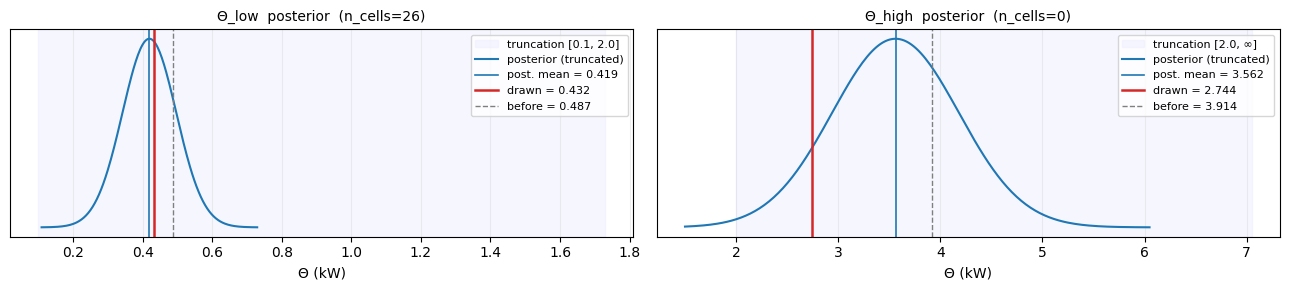


  ── Block C: sample z^LDS | z^EV, Θ  (Kalman FFBS) ───────────────────
    mean |Δ(C z^LDS)| across (d,t) = 0.0361 kW
    std of after - before          = 0.0497 kW


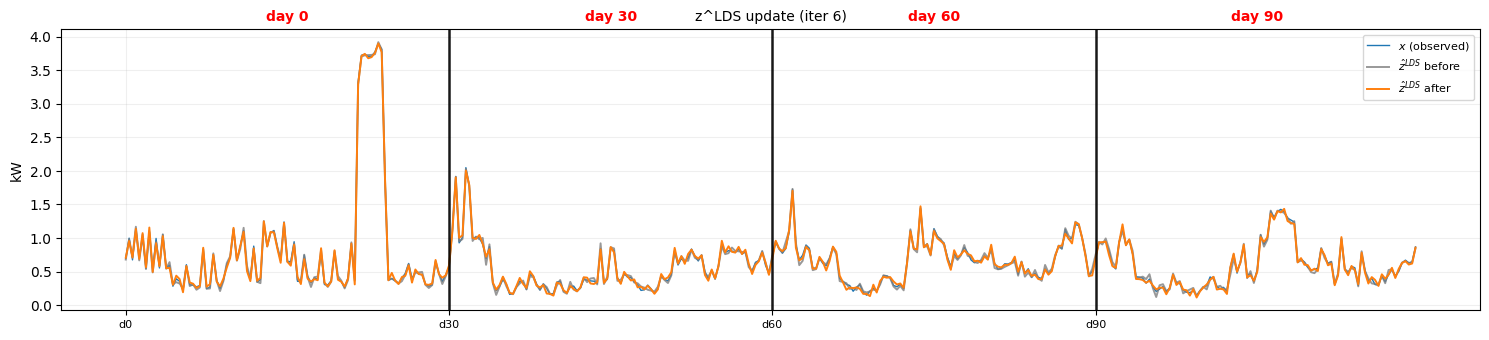


  ── End of iter 6:  complete-data logL = +35756.69
    Power decomposition (predicted vs true) across the chosen days:


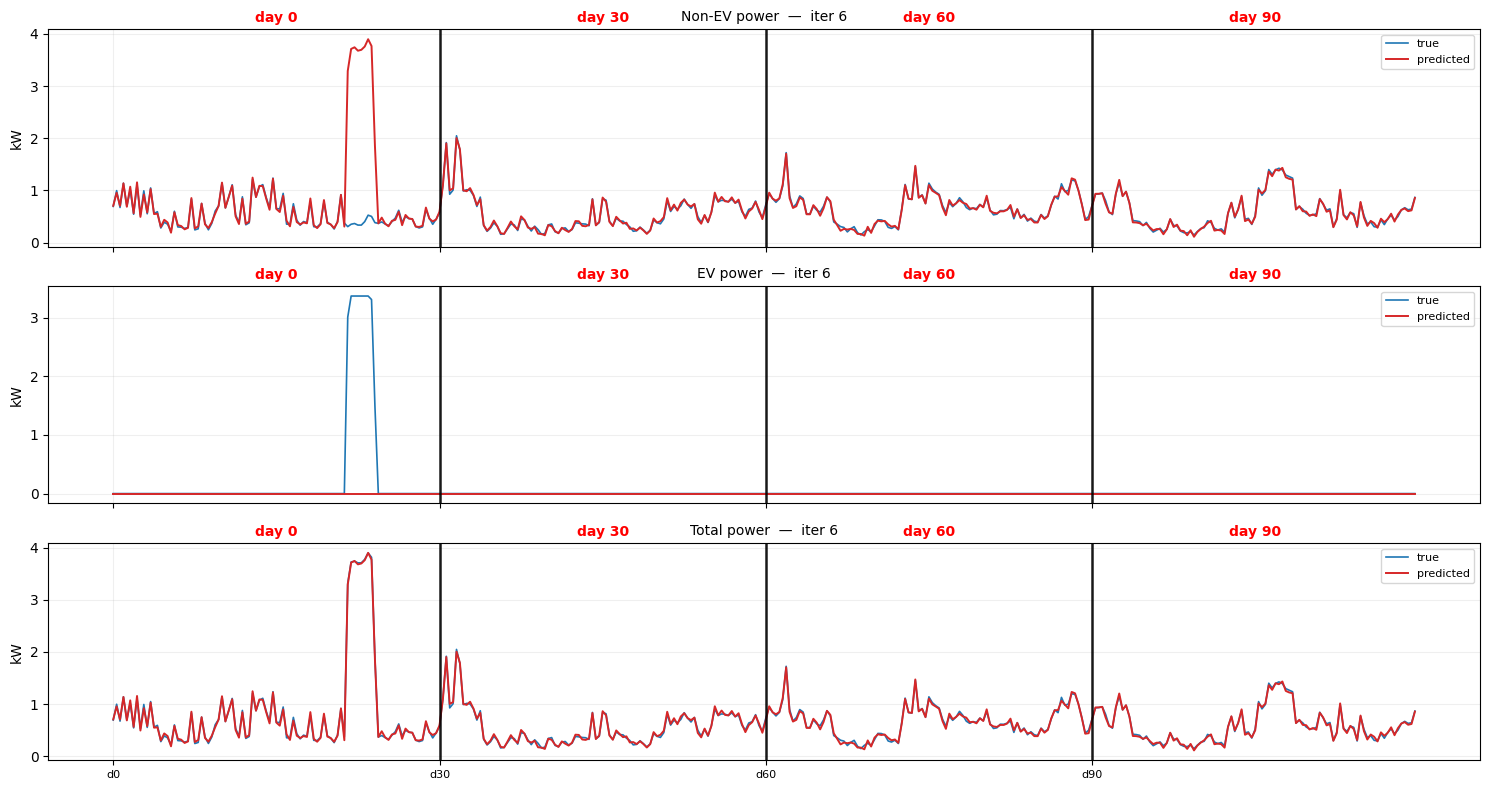


══════════════════════════════════════════════════════════════════════════════
  Iteration 7   (C = 1 fixed)
══════════════════════════════════════════════════════════════════════════════

  ── Block A: sample z^EV | Θ, z^LDS  (HMM FFBS) ──────────────────────
    state freq before : off=0.999 low=0.001 high=0.000
    state freq after  : off=0.998 low=0.002 high=0.000
    cells changed     : 26 / 17,568


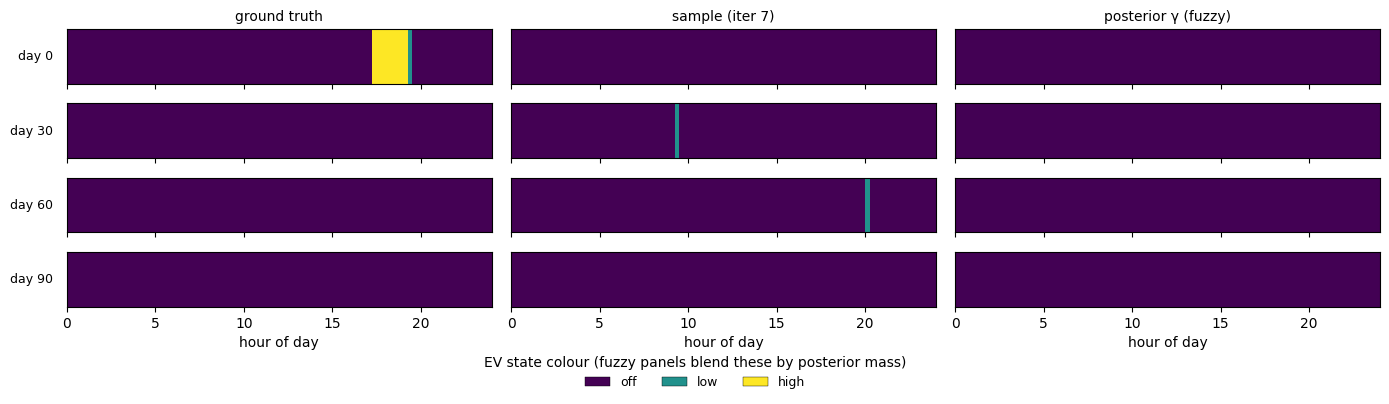


  ── Block B: sample Θ_k for k ∈ {low, high} ──────────────────────────
    Θ_ low  : m=+0.3212  sd=0.0679  trunc=[0.1, 2.0]  n_cells=   38   →  drawn=+0.3218
    Θ_high  : m=+3.5616  sd=0.6219  trunc=[2.0, ∞]  n_cells=    0   →  drawn=+3.3056  (no z=k cells — sampled from prior)


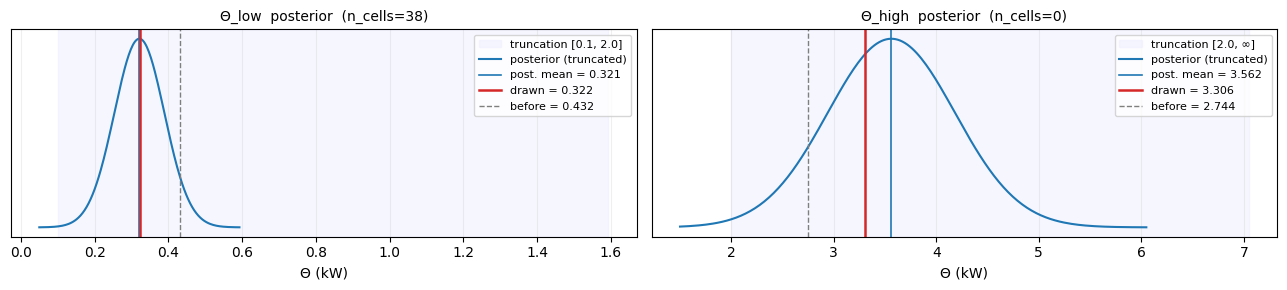


  ── Block C: sample z^LDS | z^EV, Θ  (Kalman FFBS) ───────────────────
    mean |Δ(C z^LDS)| across (d,t) = 0.0365 kW
    std of after - before          = 0.0540 kW


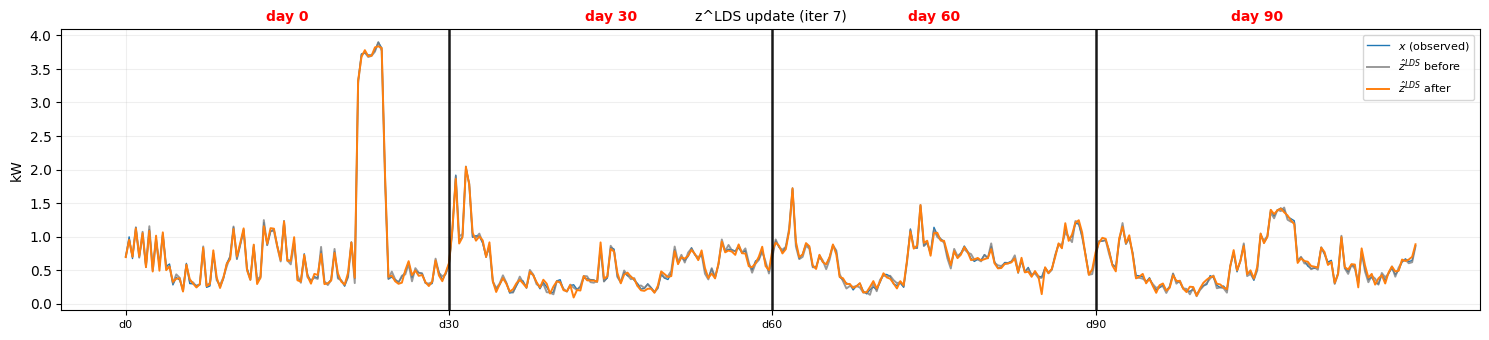


  ── End of iter 7:  complete-data logL = +35672.68
    Power decomposition (predicted vs true) across the chosen days:


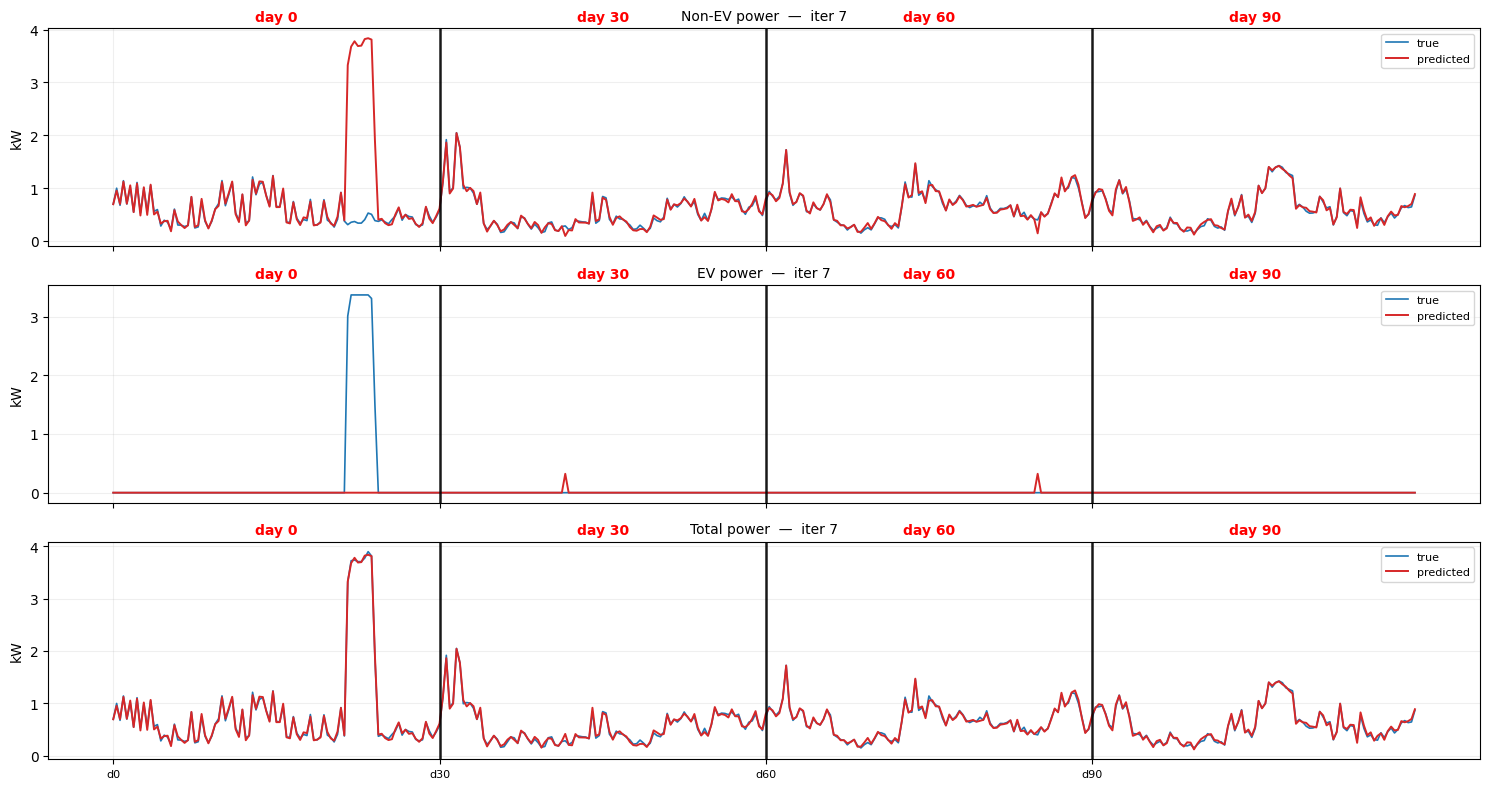


══════════════════════════════════════════════════════════════════════════════
  Iteration 8   (C = 1 fixed)
══════════════════════════════════════════════════════════════════════════════

  ── Block A: sample z^EV | Θ, z^LDS  (HMM FFBS) ──────────────────────
    state freq before : off=0.998 low=0.002 high=0.000
    state freq after  : off=0.998 low=0.002 high=0.000
    cells changed     : 22 / 17,568


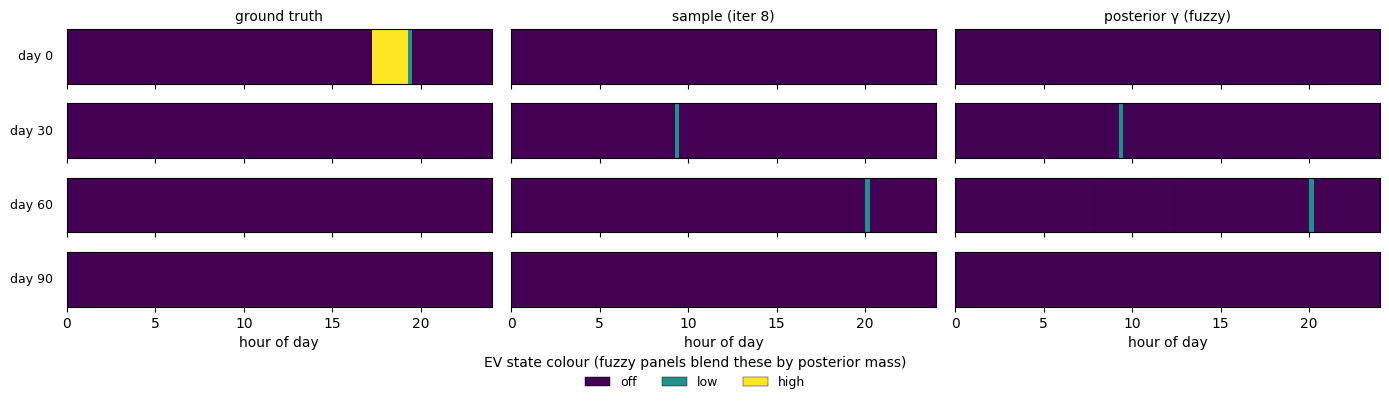


  ── Block B: sample Θ_k for k ∈ {low, high} ──────────────────────────
    Θ_ low  : m=+0.4277  sd=0.0666  trunc=[0.1, 2.0]  n_cells=   40   →  drawn=+0.4701
    Θ_high  : m=+2.7262  sd=0.4757  trunc=[2.0, ∞]  n_cells=    1   →  drawn=+3.4142


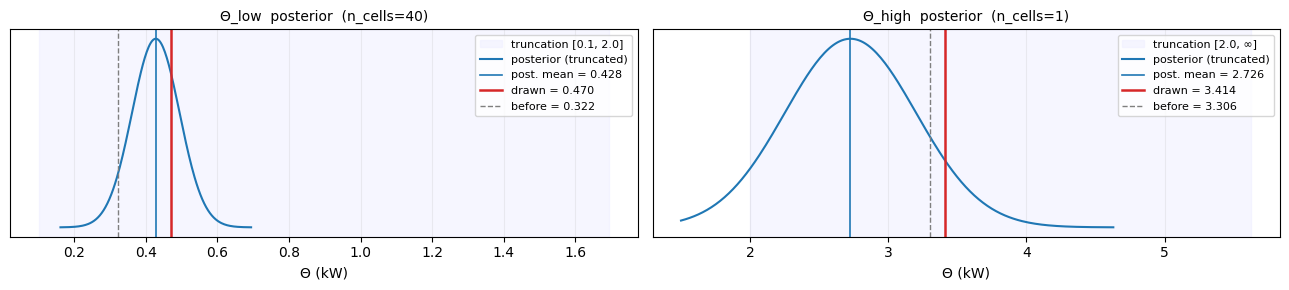


  ── Block C: sample z^LDS | z^EV, Θ  (Kalman FFBS) ───────────────────
    mean |Δ(C z^LDS)| across (d,t) = 0.0364 kW
    std of after - before          = 0.0547 kW


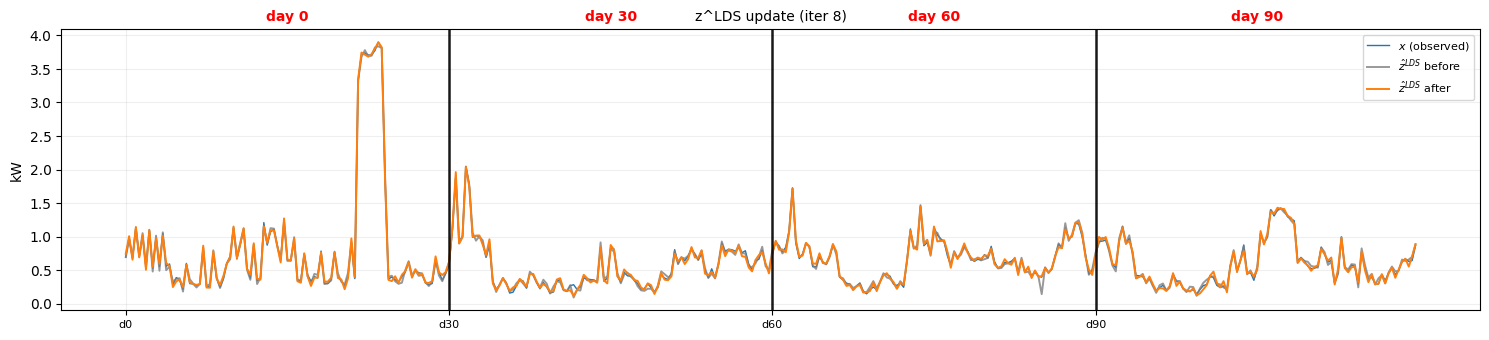


  ── End of iter 8:  complete-data logL = +35586.89
    Power decomposition (predicted vs true) across the chosen days:


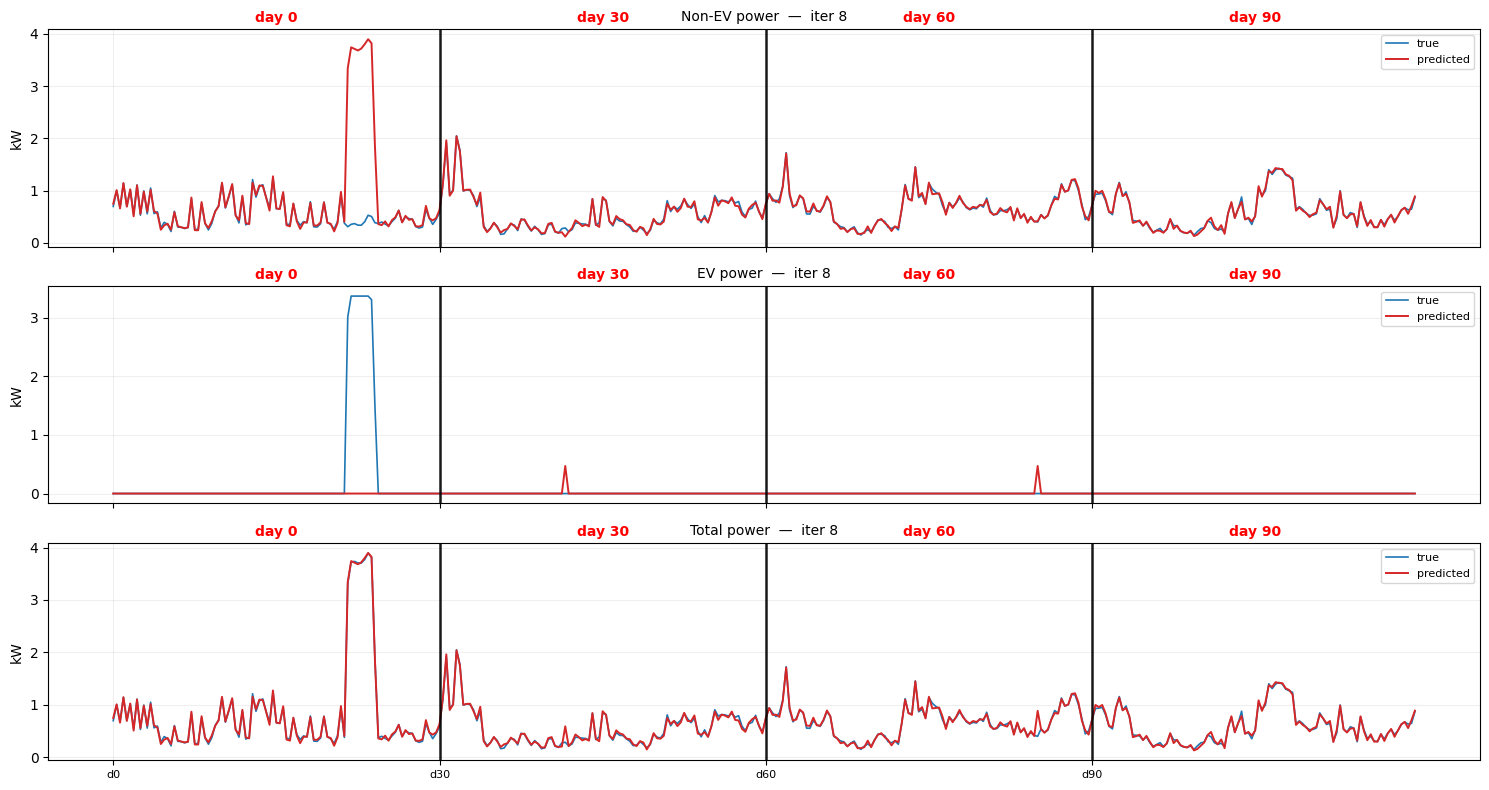


══════════════════════════════════════════════════════════════════════════════
  Iteration 9   (C = 1 fixed)
══════════════════════════════════════════════════════════════════════════════

  ── Block A: sample z^EV | Θ, z^LDS  (HMM FFBS) ──────────────────────
    state freq before : off=0.998 low=0.002 high=0.000
    state freq after  : off=0.998 low=0.002 high=0.000
    cells changed     : 19 / 17,568


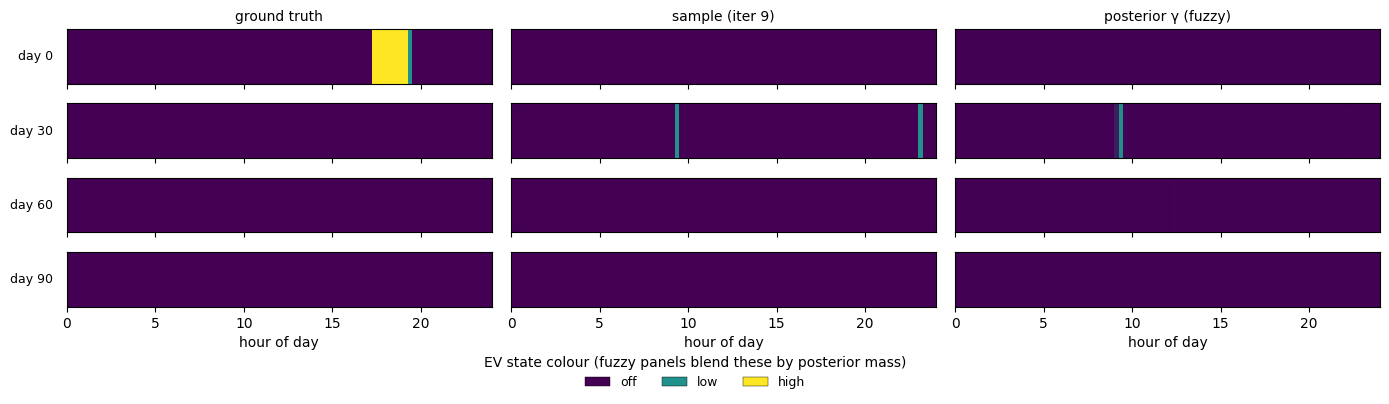


  ── Block B: sample Θ_k for k ∈ {low, high} ──────────────────────────
    Θ_ low  : m=+0.5326  sd=0.0672  trunc=[0.1, 2.0]  n_cells=   39   →  drawn=+0.3818
    Θ_high  : m=+3.6915  sd=0.4757  trunc=[2.0, ∞]  n_cells=    1   →  drawn=+4.0162


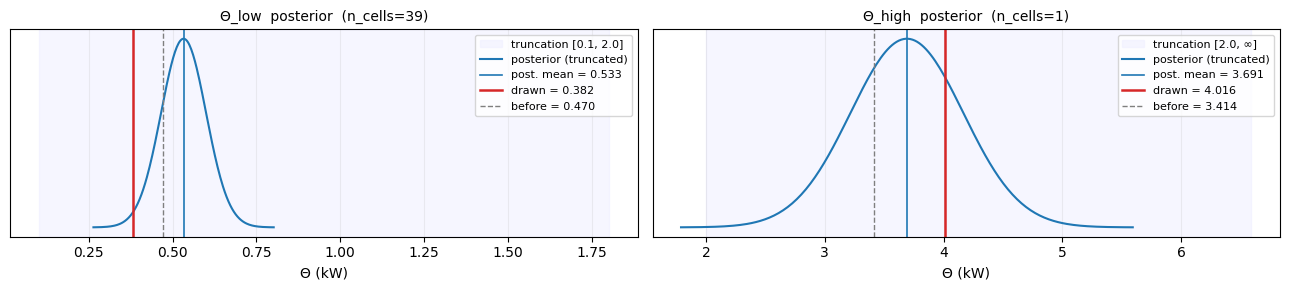


  ── Block C: sample z^LDS | z^EV, Θ  (Kalman FFBS) ───────────────────
    mean |Δ(C z^LDS)| across (d,t) = 0.0366 kW
    std of after - before          = 0.0527 kW


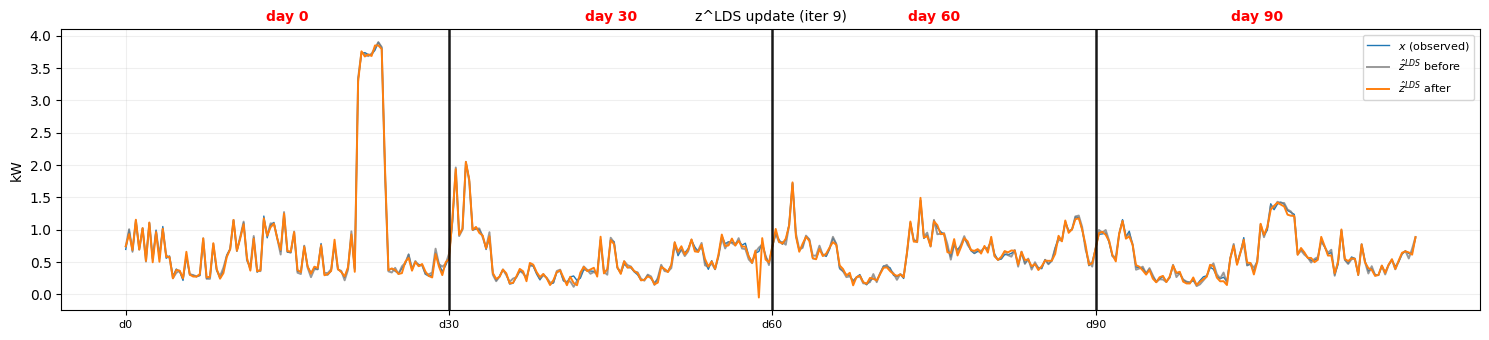


  ── End of iter 9:  complete-data logL = +35475.12
    Power decomposition (predicted vs true) across the chosen days:


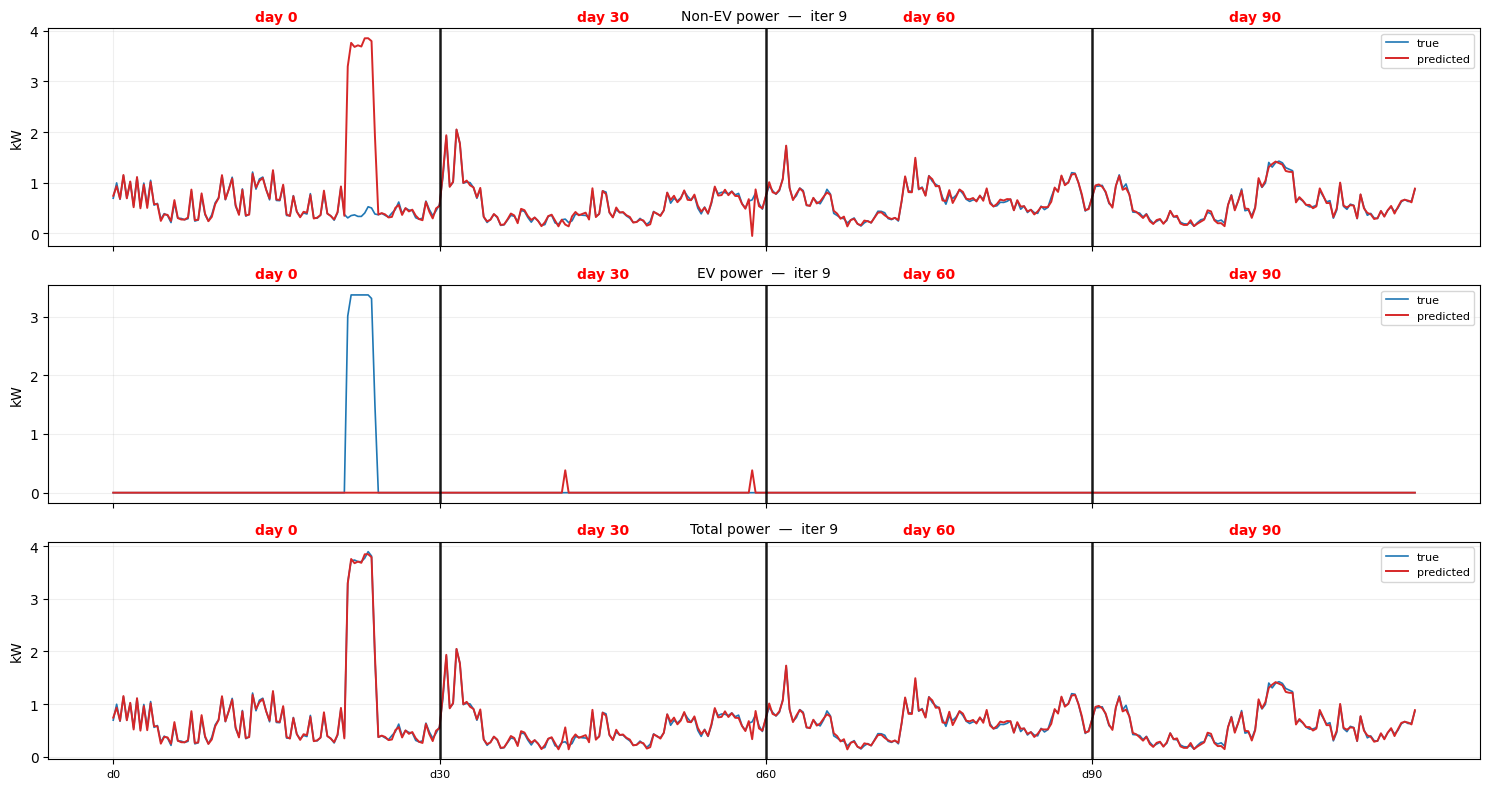

In [18]:
for rec in records:
    gd.narrate_iteration(
        record       = rec,
        z_true       = z_true,
        home_x       = home_x,
        x_nev_true   = x_nev_true,
        x_ev_true    = x_ev_true,
        days_to_show = DAYS_TO_SHOW,
    )

## 6. Traces over the narrated range

Three panels:

- complete-data $\log L$ at the end of each narrated iter
- z^EV state occupancy (fraction of cells off / low / high) per iter
- $\Theta_{\mathrm{low}}$, $\Theta_{\mathrm{high}}$ trace; shaded regions are
  the truncation bounds.

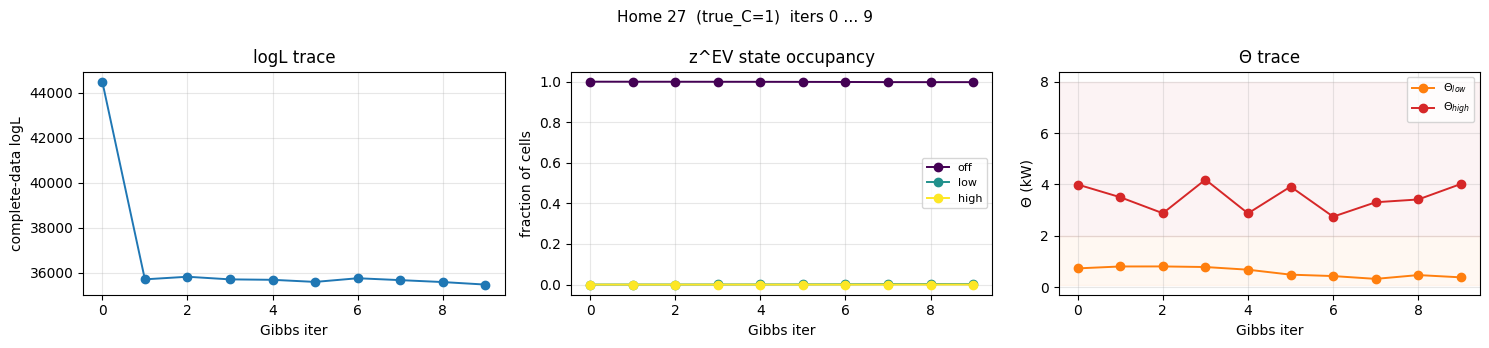

In [19]:
fig, axes = plt.subplots(1, 3, figsize=(15, 3.5))
gd.plot_traces(axes[0], axes[1], axes[2], records)
fig.suptitle(f'Home {HOME_ID}  (true_C={true_c})  iters '
             f'{records[0].iter_idx} … {records[-1].iter_idx}',
             fontsize=11)
plt.tight_layout(); plt.show()

## 7. C=0 (exact) and the model comparison

`infer_home` runs **both** tracks and compares them:

- **C = 0**: one Kalman smoother → exact posterior over z^LDS and the marginal
  $\log p(x \mid C{=}0)$ (z^LDS integrated out). Evidence
  $\log p(x, C{=}0) = \log(1-p_C) + \log p(x\mid C{=}0)$.
- **C = 1**: the three-block Gibbs above (run to convergence here), then the
  evidence $\log p(x, C{=}1)$ is estimated two ways here, and exactly in §7b:
  - **(A) plug-in joint** $\log p(x, z^{EV*}, z^{LDS*}\mid C{=}1,\Theta^*)$ —
    cheap but **not directly comparable to $\log p(x,C{=}0)$**: it is a joint
    density that *includes* the $\sim\!D\!\times\!L$-dim $z^{LDS}$ latent, so it
    lives in a higher-dimensional space and is off by the (large) $z^{LDS}$
    prior density.
  - **(A′) z^LDS-marginal** $\log(p_C) + \log p(z^{EV*}\mid C{=}1) + \log p(x\mid
    z^{EV*}, C{=}1, \Theta^*)$, where the last term integrates $z^{LDS}$
    exactly via the Kalman marginal. This **is** a density over $x$ alone, so it
    *is* comparable to $\log p(x,C{=}0)$. We use A′ for the verdict here.

A′ plugs in the discrete $z^{EV*}$ rather than marginalising it; §7b removes that
last approximation with the exact Chib estimator (B).

In [20]:
# ── CONFIGURE (model comparison) ────────────────────────────────────────────
CMP_S_BURN = 200      # C=1 Gibbs burn-in for the comparison run
CMP_S      = 500      # C=1 Gibbs retained sweeps
# ────────────────────────────────────────────────────────────────────────────

res = gm.infer_home(
    home_x, params,
    S_burn = CMP_S_BURN, S = CMP_S,
    rng    = np.random.default_rng(SEED),
    home_id= HOME_ID, decision='rb', verbose=True,
)

c0, c1 = res.c0, res.c1
print('\n' + '═' * 64)
print(f'  MODEL COMPARISON — home {HOME_ID}  (true_C = {true_c})')
print('═' * 64)
print(f'  log p(x | C=0)            = {c0.log_lik:+12.2f}')
print(f'  log p(x, C=0)             = {c0.log_evidence:+12.2f}   [exact]')
print('  ' + '-' * 60)
print(f'  log p(x, C=1)  (A  plug-in joint)  = {c1.log_evidence_plugin:+12.2f}'
      '   [NOT comparable — includes z^LDS prior]')
print(f'  log p(x, C=1)  (A′ z^LDS-marginal) = {c1.log_evidence_rb:+12.2f}'
      '   [comparable]')
print('  ' + '-' * 60)
print(f'  Δ = log p(x,C=1)[A′] − log p(x,C=0) = '
      f'{c1.log_evidence_rb - c0.log_evidence:+12.2f}')
print(f'  P(C=1 | x)  (from A′)     = {res.c_prob:.6f}')
print(f'  Ĉ = {res.C_hat}        true_C = {true_c}        '
      f'{"✓ correct" if res.C_hat == true_c else "✗ WRONG"}')

  [home 27] C=0 (exact): log p(x|C=0)=-26388.6  log p(x,C=0)=-26388.7
  [home 27] D=183 → C=1 Gibbs (200 burn-in + 500 retained)
    iter    1/700 [burn-in]  Θ_low=0.730  Θ_high=3.995  logL=44493.4  (0.1s)
    iter    2/700 [burn-in]  Θ_low=0.805  Θ_high=3.501  logL=35707.9  (0.2s)
    iter    3/700 [burn-in]  Θ_low=0.807  Θ_high=2.877  logL=35823.3  (0.3s)
    iter  100/700 [burn-in]  Θ_low=0.603  Θ_high=3.155  logL=34554.8  (9.8s)
    iter  200/700 [burn-in]  Θ_low=0.843  Θ_high=3.177  logL=34307.1  (19.6s)
    iter  201/700 [keep  ]  Θ_low=0.851  Θ_high=3.136  logL=34046.0  (19.7s)
    iter  300/700 [keep  ]  Θ_low=0.943  Θ_high=3.236  logL=33921.1  (29.5s)
    iter  400/700 [keep  ]  Θ_low=0.943  Θ_high=3.163  logL=33610.2  (39.5s)
    iter  500/700 [keep  ]  Θ_low=0.753  Θ_high=3.192  logL=33506.7  (49.4s)
    iter  600/700 [keep  ]  Θ_low=0.809  Θ_high=3.249  logL=33106.4  (59.4s)
    iter  700/700 [keep  ]  Θ_low=0.676  Θ_high=3.170  logL=32692.7  (69.4s)
  [home 27] C=1 done in

### 7b. Exact marginal via Chib (B)

`infer_home_c1(..., compute_chib=True)` turns the A′ estimate into the **exact**
$\log p(x\mid C{=}1)$ (up to Monte-Carlo error) via the Chib (1995)
decomposition (specs §5, B):

$$\log p(x\mid C{=}1)=\log p(x\mid\psi^*)+\log p(\psi^*)-\underbrace{\big[\,\log p(z^{EV*}\mid x)+\log p(\Theta^*\mid x,z^{EV*})+\log p(z^{LDS*}\mid x,z^{EV*},\Theta^*)\,\big]}_{\text{posterior ordinate}}$$

It costs one extra **reduced run** (z^EV pinned to the MAP, sampling Θ and
z^LDS), so it's slower than A/A′. The cell reports the ordinate breakdown and
the three estimates side by side.

The **cross-check** line is the key correctness signal: the Gaussian
sub-identity must reproduce A′'s z^LDS-marginal term exactly, so `Δ` should be
≈ 0 (numerical only — no Monte-Carlo error in that sub-identity).

In [ ]:
# ── CONFIGURE (Chib / B) ─────────────────────────────────────────────────────
M_CHIB      = 100   # full-posterior (Θ, z^LDS) draws for the z^EV ordinate
G_CHIB_BURN = 100   # reduced-run burn-in (z^EV pinned at MAP)
G_CHIB      = 300   # reduced-run retained sweeps for the Θ ordinate
# ─────────────────────────────────────────────────────────────────────────────

c1b = gm.infer_home_c1(
    home_x, params,
    S_burn = CMP_S_BURN, S = CMP_S,
    rng    = np.random.default_rng(SEED),
    home_id= HOME_ID, verbose=False,
    compute_chib=True, M_chib=M_CHIB, G_chib_burn=G_CHIB_BURN, G_chib=G_CHIB,
)
ch = c1b.chib

print('═' * 64)
print(f'  CHIB (B) — home {HOME_ID}  (true_C = {true_c})')
print('═' * 64)
print('  Identity:  log p(x|C=1) = log p(x|ψ*) + log p(ψ*) − log p(ψ*|x)')
print(f'    log p(x | ψ*)            = {ch.log_lik_star:+12.2f}')
print(f'    log p(ψ*)                = {ch.log_prior_star:+12.2f}')
print(f'    log p(ψ* | x)            = {ch.ord_zev + ch.ord_theta + ch.ord_zlds:+12.2f}')
print(f'      ├─ ord log p(z^EV* | x)              = {ch.ord_zev:+12.2f}   [main-run avg]')
print(f'      ├─ ord log p(Θ* | x, z^EV*)          = {ch.ord_theta:+12.2f}   [reduced run]')
print(f'      └─ ord log p(z^LDS* | x, z^EV*, Θ*)  = {ch.ord_zlds:+12.2f}   [closed form]')
print('  ' + '-' * 60)
print(f'  log p(x | C=1)  (B, exact)  = {ch.log_lik_c1:+12.2f}')
print(f'  log p(x, C=1)   (B)         = {ch.log_evidence:+12.2f}')
print('  ' + '-' * 60)
print('  Three estimates of log p(x, C=1), side by side:')
print(f'    A  (plug-in joint)   = {c1b.log_evidence_plugin:+12.2f}   [not comparable to C=0]')
print(f"    A′ (z^LDS-marginal)  = {c1b.log_evidence_rb:+12.2f}")
print(f'    B  (Chib, exact)     = {c1b.log_evidence_chib:+12.2f}')
print(f'    log p(x, C=0)        = {c0.log_evidence:+12.2f}   [exact]')
print('  ' + '-' * 60)
print(f'  Δ(B) = log p(x,C=1)[B] − log p(x,C=0) = {c1b.log_evidence_chib - c0.log_evidence:+12.2f}')
print(f'  CROSS-CHECK (z^LDS-marg, should match): direct={ch.lds_marg_direct:+.3f}  '
      f'via-Chib={ch.lds_marg_via_chib:+.3f}  Δ={ch.lds_marg_via_chib - ch.lds_marg_direct:+.4f}')

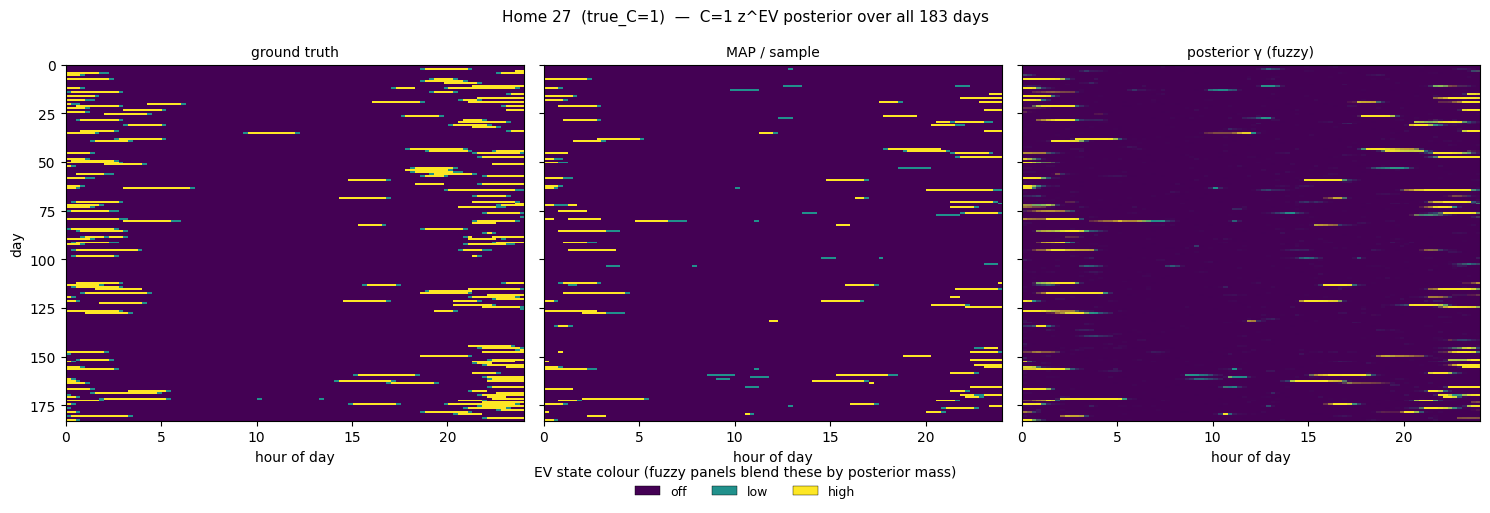

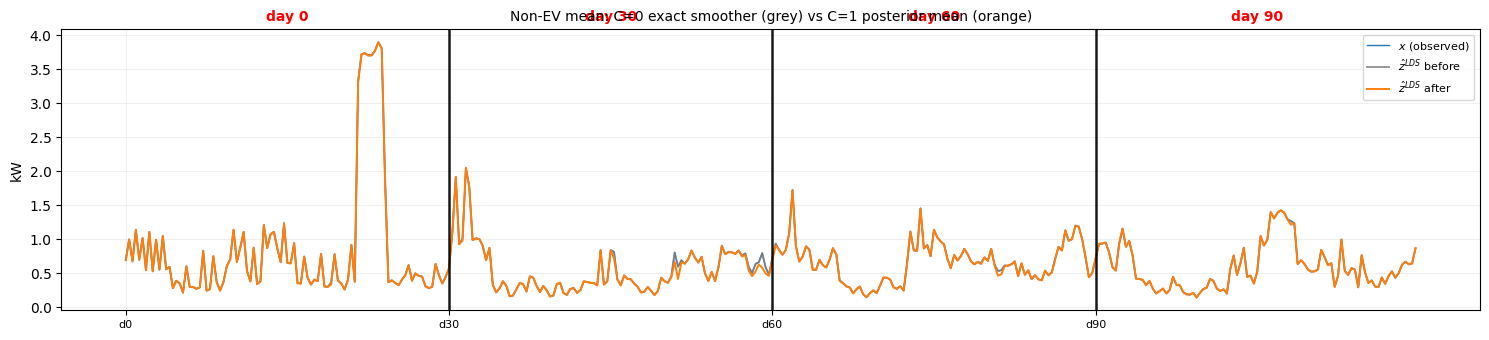

In [21]:
# Full-D z^EV under C=1: truth | MAP | posterior blend (all days at once).
fig = plt.figure(figsize=(15, 5))
gd.plot_z_ev_full(
    fig,
    z_true      = z_true,
    z_pred      = c1.z_hat,
    z_marginals = c1.z_marginals,
    title       = f'Home {HOME_ID}  (true_C={true_c})  —  C=1 z^EV posterior over all {D} days',
)
plt.tight_layout(rect=(0, 0.04, 1, 1)); plt.show()

# C=0 exact Non-EV fit vs observed, for the selected days.
fig, ax = plt.subplots(figsize=(15, 3.5))
gd.plot_z_lds_compare(
    ax, home_x,
    nonev_before = c0.z_lds_mean,    # exact C=0 smoother mean (no EV)
    nonev_after  = c1.z_lds_mean,    # C=1 posterior-mean Non-EV (EV removed)
    days_to_show = DAYS_TO_SHOW,
    title        = 'Non-EV mean: C=0 exact smoother (grey) vs C=1 posterior mean (orange)',
)
plt.tight_layout(); plt.show()